# Brain Tumor Classification: 7-Model Comprehensive Comparison
## Complete Pipeline — 5-Fold CV (All 7 Models) + Test Evaluation + Figures + Statistics

**Models:** CNN, ViT, Hybrid CNN-ViT, ResNet50 Frozen, ResNet50 Fine-Tuned, DenseNet121 Frozen, DenseNet121 Fine-Tuned

**Before running:**
1. Runtime → Change runtime type → **T4 GPU** → Save
2. Dataset should be on Google Drive at: `Epic and CSCR hospital Dataset/`
3. Run cells one by one and share output back


---
## CELL 1: Environment Setup + GPU + Dataset Verification

In [ ]:
# =============================================================================
# CELL 1: Mount Drive, Verify GPU, Copy Dataset Locally, Verify Structure
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import os, shutil, time

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    raise RuntimeError("NO GPU DETECTED! Go to Runtime → Change runtime type → T4 GPU")
print("GPU ready\n")

# --- Dataset paths ---
DATA_ROOT_DRIVE = "/content/drive/MyDrive/Epic and CSCR hospital Dataset"
DATA_ROOT = "/content/dataset"  # Local copy for fast I/O

assert os.path.exists(DATA_ROOT_DRIVE), f"Dataset not found at: {DATA_ROOT_DRIVE}"

# Copy to local storage (much faster than reading from Drive)
if not os.path.exists(DATA_ROOT):
    print("Copying dataset to local storage (faster I/O)...")
    t0 = time.time()
    shutil.copytree(DATA_ROOT_DRIVE, DATA_ROOT)
    print(f"Done in {time.time()-t0:.0f}s")
else:
    print("Dataset already copied locally")

# Verify structure
print(f"\nDataset structure:")
total_train, total_test = 0, 0
for split in ['Train', 'Test']:
    sp = os.path.join(DATA_ROOT, split)
    for cls in sorted(os.listdir(sp)):
        cp = os.path.join(sp, cls)
        if os.path.isdir(cp):
            n = len([f for f in os.listdir(cp) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
            print(f"  {split}/{cls}: {n} images")
            if split == 'Train': total_train += n
            else: total_test += n

print(f"\nTotal — Train: {total_train} | Test: {total_test} | All: {total_train + total_test}")

# Output directories
FIG_DIR = "/content/figures"
SAVE_DIR = "/content/drive/MyDrive/Brain_Tumor_Results"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"\nFigures will be saved to: {SAVE_DIR}")
print("\n=== CELL 1 COMPLETE ===")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU ready

Copying dataset to local storage (faster I/O)...
Done in 253s

Dataset structure:
  Train/glioma: 3018 images
  Train/meningioma: 2183 images
  Train/notumor: 1945 images
  Train/pituitary: 2504 images
  Test/glioma: 755 images
  Test/meningioma: 546 images
  Test/notumor: 487 images
  Test/pituitary: 626 images

Total — Train: 9650 | Test: 2414 | All: 12064

Figures will be saved to: /content/drive/MyDrive/Brain_Tumor_Results

=== CELL 1 COMPLETE ===


---
## CELL 2: Imports, Config & Data Pipeline

In [ ]:
# =============================================================================
# CELL 2: All Imports, Constants, Data Loading & Pipeline
# =============================================================================

import numpy as np
import pandas as pd
import json, warnings
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 10
import seaborn as sns
import cv2

from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score, precision_score,
                             recall_score, accuracy_score)
from sklearn.manifold import TSNE
from scipy.stats import wilcoxon, chi2

warnings.filterwarnings('ignore')

# --- Constants ---
IMG_SIZE = (224, 224)
NUM_CLASSES = 4
EPOCHS = 20
N_FOLDS = 5
SEED = 42

CLASS_NAMES = sorted([
    c for c in os.listdir(os.path.join(DATA_ROOT, 'Train'))
    if os.path.isdir(os.path.join(DATA_ROOT, 'Train', c))
])
print(f"Classes: {CLASS_NAMES}")

# --- Load file paths and labels ---
def load_paths_labels(root, split):
    paths, labels = [], []
    for ci, cn in enumerate(CLASS_NAMES):
        d = os.path.join(root, split, cn)
        if not os.path.isdir(d): continue
        for f in sorted(os.listdir(d)):
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
                paths.append(os.path.join(d, f))
                labels.append(ci)
    return np.array(paths), np.array(labels)

all_train_paths, all_train_labels = load_paths_labels(DATA_ROOT, 'Train')
test_paths, test_labels = load_paths_labels(DATA_ROOT, 'Test')

print(f"Train: {len(all_train_paths)} | Test: {len(test_paths)}")
print(f"Train distribution: {dict(sorted(Counter(all_train_labels).items()))}")
print(f"Test distribution:  {dict(sorted(Counter(test_labels).items()))}")

# --- tf.data pipeline ---
def create_dataset(paths, labels, batch_size=32, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)

    def _parse(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, tf.one_hot(label, NUM_CLASSES)

    def _augment(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        return tf.clip_by_value(img, 0.0, 1.0), label

    ds = ds.map(_parse, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create test dataset (used throughout)
test_dataset = create_dataset(test_paths, test_labels, augment=False, shuffle=False)
print(f"\nPipeline ready")
print("\n=== CELL 2 COMPLETE ===")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 9650 | Test: 2414
Train distribution: {np.int64(0): 3018, np.int64(1): 2183, np.int64(2): 1945, np.int64(3): 2504}
Test distribution:  {np.int64(0): 755, np.int64(1): 546, np.int64(2): 487, np.int64(3): 626}

Pipeline ready

=== CELL 2 COMPLETE ===


---
## CELL 3: Model Architecture Definitions

In [ ]:
# =============================================================================
# CELL 3: All 7 Model Architectures
# =============================================================================

# --- 1. CNN (From Scratch) — Functional API for Grad-CAM compatibility ---
def build_cnn(input_shape=(224,224,3), num_classes=4):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', name='conv1')(inp)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', name='conv2')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu', name='conv3')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu', name='features')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name='CNN')


# --- 2. Vision Transformer (From Scratch) ---
class Patches(layers.Layer):
    def __init__(self, patch_size, **kw):
        super().__init__(**kw)
        self.patch_size = patch_size
    def call(self, images):
        bs = tf.shape(images)[0]
        p = tf.image.extract_patches(
            images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1], padding='VALID')
        return tf.reshape(p, [bs, -1, p.shape[-1]])
    def get_config(self):
        return {**super().get_config(), 'patch_size': self.patch_size}

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, proj_dim, **kw):
        super().__init__(**kw)
        self.num_patches = num_patches
        self.proj_dim = proj_dim
        self.projection = layers.Dense(proj_dim)
        self.pos_emb = layers.Embedding(num_patches + 1, proj_dim)
    def build(self, input_shape):
        self.cls_tok = self.add_weight(
            shape=(1, 1, self.proj_dim),
            initializer='random_normal', name='cls')
        super().build(input_shape)
    def call(self, patches):
        bs = tf.shape(patches)[0]
        proj = self.projection(patches)
        cls = tf.broadcast_to(self.cls_tok, [bs, 1, self.proj_dim])
        proj = tf.concat([cls, proj], axis=1)
        return proj + self.pos_emb(tf.range(self.num_patches + 1))
    def get_config(self):
        return {**super().get_config(),
                'num_patches': self.num_patches, 'proj_dim': self.proj_dim}

def build_vit(input_shape=(224,224,3), num_classes=4, patch_size=16,
              proj_dim=64, num_heads=4, n_blocks=8):
    num_patches = (input_shape[0] // patch_size) ** 2
    inp = layers.Input(shape=input_shape)
    enc = PatchEncoder(num_patches, proj_dim)(Patches(patch_size)(inp))
    for _ in range(n_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(enc)
        attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=proj_dim)(x1, x1)
        x2 = layers.Add()([attn, enc])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(proj_dim * 2, activation='gelu')(x3)
        x3 = layers.Dense(proj_dim)(x3)
        enc = layers.Add()([x3, x2])
    x = layers.GlobalAveragePooling1D()(layers.LayerNormalization(epsilon=1e-6)(enc))
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64, activation='gelu')(x)
    x = layers.Dropout(0.1)(x)
    return Model(inp, layers.Dense(num_classes, activation='softmax')(x), name='ViT')


# --- 3. Hybrid CNN-ViT (From Scratch) ---
def build_hybrid(input_shape=(224,224,3), num_classes=4,
                 proj_dim=64, num_heads=4, n_blocks=4):
    num_patches = (input_shape[0] // 16) ** 2
    inp = layers.Input(shape=input_shape)
    # CNN branch (same padding)
    c = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    c = layers.MaxPooling2D((2,2))(c)
    c = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c)
    c = layers.MaxPooling2D((2,2))(c)
    c = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c)
    c = layers.MaxPooling2D((2,2))(c)
    cnn_feat = layers.GlobalAveragePooling2D()(c)
    # ViT branch
    enc = PatchEncoder(num_patches, proj_dim)(Patches(16)(inp))
    for _ in range(n_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(enc)
        attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=proj_dim)(x1, x1)
        x2 = layers.Add()([attn, enc])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(proj_dim * 2, activation='gelu')(x3)
        x3 = layers.Dense(proj_dim)(x3)
        enc = layers.Add()([x3, x2])
    vit_feat = layers.GlobalAveragePooling1D()(enc)
    # Merge
    x = layers.Concatenate()([cnn_feat, vit_feat])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inp, layers.Dense(num_classes, activation='softmax')(x), name='Hybrid_CNN_ViT')


# --- 4-7. Pretrained Model Builder ---
def _build_pretrained(base_cls, preproc_fn, name, finetune_layers=0):
    base = base_cls(weights='imagenet', include_top=False, input_shape=(224,224,3))
    if finetune_layers == 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-finetune_layers]:
            layer.trainable = False
    inp = layers.Input(shape=(224,224,3))
    x = layers.Lambda(lambda img: preproc_fn(img * 255.0))(inp)
    x = base(x, training=(finetune_layers > 0))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', name='feat128')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inp, layers.Dense(4, activation='softmax')(x), name=name)

def build_resnet50_frozen():
    return _build_pretrained(ResNet50, tf.keras.applications.resnet50.preprocess_input,
                             'ResNet50_Frozen', 0)
def build_densenet121_frozen():
    return _build_pretrained(DenseNet121, tf.keras.applications.densenet.preprocess_input,
                             'DenseNet121_Frozen', 0)
def build_resnet50_ft():
    return _build_pretrained(ResNet50, tf.keras.applications.resnet50.preprocess_input,
                             'ResNet50_FineTuned', 20)
def build_densenet121_ft():
    return _build_pretrained(DenseNet121, tf.keras.applications.densenet.preprocess_input,
                             'DenseNet121_FineTuned', 30)


# --- Model Registry ---
MODEL_CONFIGS = {
    'CNN':                   {'build_fn': build_cnn,             'lr': 1e-3, 'bs': 32},
    'ViT':                   {'build_fn': build_vit,             'lr': 1e-3, 'bs': 32},
    'Hybrid_CNN_ViT':        {'build_fn': build_hybrid,          'lr': 1e-4, 'bs': 48},
    'ResNet50_Frozen':       {'build_fn': build_resnet50_frozen, 'lr': 1e-3, 'bs': 32},
    'DenseNet121_Frozen':    {'build_fn': build_densenet121_frozen, 'lr': 1e-3, 'bs': 32},
    'ResNet50_FineTuned':    {'build_fn': build_resnet50_ft,     'lr': 1e-4, 'bs': 32},
    'DenseNet121_FineTuned': {'build_fn': build_densenet121_ft,  'lr': 1e-4, 'bs': 32},
}

# Verify all models build correctly & print parameter counts
print(f"{'Model':<28} {'Total Params':>14} {'Trainable':>14}")
print('=' * 60)
for name, cfg in MODEL_CONFIGS.items():
    m = cfg['build_fn']()
    total = int(np.sum([np.prod(v.shape) for v in m.weights]))
    trainable = int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))
    print(f"  {name:<26} {total:>12,} {trainable:>14,}")
    del m
    tf.keras.backend.clear_session()

print("\n=== CELL 3 COMPLETE ===")

Model                          Total Params      Trainable
  CNN                          11,169,476     11,169,476
  ViT                             744,452        744,452
  Hybrid_CNN_ViT                  513,156        513,156
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  ResNet50_Frozen              24,145,668        557,956
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  DenseNet121_Frozen            7,333,316        295,812
  ResNet50_FineTuned           24,145,668      9,489,284
  DenseNet121_FineTuned         7,333,316        937,220

=== CELL 3 COMPLETE ===


---
## CELL 4: 5-Fold Cross-Validation — ALL 7 Models

**This is the longest cell (~3-4 hours).** Progress is printed per fold and checkpointed to Drive after each model.

If your session disconnects, set `RESUME_FROM` to the name of the model to resume from (e.g., `'ResNet50_Frozen'`). Models before it will be loaded from the checkpoint.

In [ ]:
# =============================================================================
# CELL 4: 5-Fold Stratified Cross-Validation for ALL 7 Models
# =============================================================================
# Set to None to run all. Set to a model name to skip models before it.
# e.g., RESUME_FROM = 'ResNet50_Frozen' will load CNN, ViT, Hybrid from checkpoint
RESUME_FROM = None

CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'cv_checkpoint.json')

# Load existing checkpoint if resuming
if RESUME_FROM and os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        all_results = json.load(f)
    print(f"Loaded checkpoint with results for: {list(all_results.keys())}")
else:
    all_results = {}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
skip = RESUME_FROM is not None

total_start = time.time()

for model_name, cfg in MODEL_CONFIGS.items():
    # Handle resume logic
    if skip:
        if model_name == RESUME_FROM:
            skip = False
        else:
            print(f"SKIPPING {model_name} (loaded from checkpoint)")
            continue

    if model_name in all_results:
        print(f"SKIPPING {model_name} (already completed)")
        continue

    print(f"\n{'='*70}")
    print(f"Training: {model_name} ({N_FOLDS}-Fold CV)")
    print(f"{'='*70}")

    fold_val_metrics = []
    fold_test_preds = []
    fold_test_probs = []
    fold_val_accuracies = []
    fold_times = []

    for fi, (tr_idx, va_idx) in enumerate(skf.split(all_train_paths, all_train_labels)):
        print(f"  Fold {fi+1}/{N_FOLDS}", end=" ... ", flush=True)

        train_ds = create_dataset(all_train_paths[tr_idx], all_train_labels[tr_idx],
                                  batch_size=cfg['bs'], augment=True)
        val_ds = create_dataset(all_train_paths[va_idx], all_train_labels[va_idx],
                                batch_size=cfg['bs'], augment=False, shuffle=False)

        tf.keras.backend.clear_session()
        model = cfg['build_fn']()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

        t0 = time.time()
        hist = model.fit(
            train_ds, validation_data=val_ds, epochs=EPOCHS,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=0)
            ], verbose=0)
        dt = time.time() - t0
        fold_times.append(dt)

        # --- Validation metrics ---
        val_probs, val_true = [], []
        for bi, bl in val_ds:
            val_probs.extend(model.predict(bi, verbose=0))
            val_true.extend(np.argmax(bl.numpy(), axis=1))
        val_probs = np.array(val_probs)
        val_true = np.array(val_true)
        val_pred = np.argmax(val_probs, axis=1)

        va_acc = accuracy_score(val_true, val_pred)
        va_f1 = f1_score(val_true, val_pred, average='weighted')
        va_prec = precision_score(val_true, val_pred, average='weighted')
        va_rec = recall_score(val_true, val_pred, average='weighted')

        fold_val_metrics.append({
            'accuracy': va_acc, 'f1_score': va_f1,
            'precision': va_prec, 'recall': va_rec
        })
        fold_val_accuracies.append(va_acc)

        # --- Test metrics ---
        test_probs, test_true = [], []
        for bi, bl in test_dataset:
            test_probs.extend(model.predict(bi, verbose=0))
            test_true.extend(np.argmax(bl.numpy(), axis=1))
        test_probs = np.array(test_probs)
        test_true = np.array(test_true)

        fold_test_preds.append(np.argmax(test_probs, axis=1).tolist())
        fold_test_probs.append(test_probs.tolist())

        test_acc = accuracy_score(test_true, np.argmax(test_probs, axis=1))
        n_epochs = len(hist.history['loss'])

        print(f"Val={va_acc:.4f} F1={va_f1:.4f} | Test={test_acc:.4f} | Ep={n_epochs} | {dt:.0f}s")

        del model
        tf.keras.backend.clear_session()

    # --- Aggregate results ---
    fdf = pd.DataFrame(fold_val_metrics)

    # SELECT BEST FOLD BY VALIDATION ACCURACY (not test!)
    best_fold = int(np.argmax(fold_val_accuracies))

    all_results[model_name] = {
        'fold_val_metrics': fold_val_metrics,
        'fold_val_accuracies': fold_val_accuracies,
        'test_predictions': fold_test_preds,
        'test_probabilities': fold_test_probs,
        'test_true': test_true.tolist(),
        'best_fold': best_fold,
        'fold_times': fold_times,
        'cv_accuracy_mean': float(fdf['accuracy'].mean()),
        'cv_accuracy_std': float(fdf['accuracy'].std()),
        'cv_f1_mean': float(fdf['f1_score'].mean()),
        'cv_f1_std': float(fdf['f1_score'].std()),
        'cv_precision_mean': float(fdf['precision'].mean()),
        'cv_precision_std': float(fdf['precision'].std()),
        'cv_recall_mean': float(fdf['recall'].mean()),
        'cv_recall_std': float(fdf['recall'].std()),
        'mean_time': float(np.mean(fold_times)),
        'n_folds': N_FOLDS,
    }

    print(f"\n  {model_name} Summary:")
    print(f"    CV Accuracy:  {fdf['accuracy'].mean():.4f} +/- {fdf['accuracy'].std():.4f}")
    print(f"    CV F1-Score:  {fdf['f1_score'].mean():.4f} +/- {fdf['f1_score'].std():.4f}")
    print(f"    Best Fold:    {best_fold+1} (Val Acc: {fold_val_accuracies[best_fold]:.4f})")
    print(f"    Avg Time:     {np.mean(fold_times):.0f}s per fold")

    # Save checkpoint after each model
    with open(CHECKPOINT_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"    Checkpoint saved to Drive")

total_time = time.time() - total_start
print(f"\n{'='*70}")
print(f"ALL CV COMPLETE — Total time: {total_time/3600:.1f} hours")
print(f"{'='*70}")
print("\n=== CELL 4 COMPLETE ===")


Training: CNN (5-Fold CV)
  Fold 1/5 ... Val=0.9575 F1=0.9577 | Test=0.9130 | Ep=20 | 421s
  Fold 2/5 ... Val=0.9580 F1=0.9580 | Test=0.9035 | Ep=20 | 370s
  Fold 3/5 ... Val=0.9508 F1=0.9510 | Test=0.9002 | Ep=20 | 354s
  Fold 4/5 ... Val=0.9575 F1=0.9575 | Test=0.8993 | Ep=20 | 357s
  Fold 5/5 ... Val=0.9642 F1=0.9642 | Test=0.9209 | Ep=20 | 364s

  CNN Summary:
    CV Accuracy:  0.9576 +/- 0.0048
    CV F1-Score:  0.9577 +/- 0.0047
    Best Fold:    5 (Val Acc: 0.9642)
    Avg Time:     373s per fold
    Checkpoint saved to Drive

Training: ViT (5-Fold CV)
  Fold 1/5 ... Val=0.8285 F1=0.8285 | Test=0.7958 | Ep=20 | 438s
  Fold 2/5 ... Val=0.8140 F1=0.8122 | Test=0.7676 | Ep=20 | 444s
  Fold 3/5 ... Val=0.7969 F1=0.7931 | Test=0.7593 | Ep=20 | 427s
  Fold 4/5 ... Val=0.8026 F1=0.8001 | Test=0.7432 | Ep=20 | 428s
  Fold 5/5 ... Val=0.8000 F1=0.7972 | Test=0.7440 | Ep=20 | 428s

  ViT Summary:
    CV Accuracy:  0.8084 +/- 0.0130
    CV F1-Score:  0.8062 +/- 0.0143
    Best Fold:    1 

In [ ]:
# =============================================================================
# CELL 4: 5-Fold Stratified Cross-Validation (RESUMED)
# =============================================================================
# RESUME: CNN, ViT, Hybrid_CNN_ViT, ResNet50_Frozen already done.
# Starting from DenseNet121_Frozen.
# =============================================================================

import gc  # <-- Fixes RAM leak between folds

RESUME_FROM = 'DenseNet121_Frozen'
CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'cv_checkpoint.json')

# Load existing checkpoint
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        all_results = json.load(f)
    print(f"Loaded checkpoint with: {list(all_results.keys())}")
else:
    all_results = {}
    print("No checkpoint found — starting fresh")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
skip = RESUME_FROM is not None

total_start = time.time()

for model_name, cfg in MODEL_CONFIGS.items():
    # Handle resume logic
    if skip:
        if model_name == RESUME_FROM:
            skip = False
        else:
            print(f"SKIPPING {model_name} (loaded from checkpoint)")
            continue

    if model_name in all_results:
        print(f"SKIPPING {model_name} (already completed)")
        continue

    print(f"\n{'='*70}")
    print(f"Training: {model_name} ({N_FOLDS}-Fold CV)")
    print(f"{'='*70}")

    fold_val_metrics = []
    fold_test_preds = []
    fold_test_probs = []
    fold_val_accuracies = []
    fold_times = []

    for fi, (tr_idx, va_idx) in enumerate(skf.split(all_train_paths, all_train_labels)):
        print(f"  Fold {fi+1}/{N_FOLDS}", end=" ... ", flush=True)

        train_ds = create_dataset(all_train_paths[tr_idx], all_train_labels[tr_idx],
                                  batch_size=cfg['bs'], augment=True)
        val_ds = create_dataset(all_train_paths[va_idx], all_train_labels[va_idx],
                                batch_size=cfg['bs'], augment=False, shuffle=False)

        tf.keras.backend.clear_session()
        gc.collect()  # <-- Force memory cleanup before building new model

        model = cfg['build_fn']()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

        t0 = time.time()
        hist = model.fit(
            train_ds, validation_data=val_ds, epochs=EPOCHS,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=0)
            ], verbose=0)
        dt = time.time() - t0
        fold_times.append(dt)

        # --- Validation metrics ---
        val_probs, val_true = [], []
        for bi, bl in val_ds:
            val_probs.extend(model.predict(bi, verbose=0))
            val_true.extend(np.argmax(bl.numpy(), axis=1))
        val_probs = np.array(val_probs)
        val_true = np.array(val_true)
        val_pred = np.argmax(val_probs, axis=1)

        va_acc = accuracy_score(val_true, val_pred)
        va_f1 = f1_score(val_true, val_pred, average='weighted')
        va_prec = precision_score(val_true, val_pred, average='weighted')
        va_rec = recall_score(val_true, val_pred, average='weighted')

        fold_val_metrics.append({
            'accuracy': va_acc, 'f1_score': va_f1,
            'precision': va_prec, 'recall': va_rec
        })
        fold_val_accuracies.append(va_acc)

        # --- Test metrics ---
        test_probs, test_true = [], []
        for bi, bl in test_dataset:
            test_probs.extend(model.predict(bi, verbose=0))
            test_true.extend(np.argmax(bl.numpy(), axis=1))
        test_probs = np.array(test_probs)
        test_true = np.array(test_true)

        fold_test_preds.append(np.argmax(test_probs, axis=1).tolist())
        fold_test_probs.append(test_probs.tolist())

        test_acc = accuracy_score(test_true, np.argmax(test_probs, axis=1))
        n_epochs = len(hist.history['loss'])

        print(f"Val={va_acc:.4f} F1={va_f1:.4f} | Test={test_acc:.4f} | Ep={n_epochs} | {dt:.0f}s")

        # Aggressive cleanup after each fold
        del model, train_ds, val_ds, hist
        del val_probs, val_true, val_pred
        del test_probs
        tf.keras.backend.clear_session()
        gc.collect()

    # --- Aggregate results ---
    fdf = pd.DataFrame(fold_val_metrics)

    # SELECT BEST FOLD BY VALIDATION ACCURACY (not test!)
    best_fold = int(np.argmax(fold_val_accuracies))

    all_results[model_name] = {
        'fold_val_metrics': fold_val_metrics,
        'fold_val_accuracies': fold_val_accuracies,
        'test_predictions': fold_test_preds,
        'test_probabilities': fold_test_probs,
        'test_true': test_true.tolist(),
        'best_fold': best_fold,
        'fold_times': fold_times,
        'cv_accuracy_mean': float(fdf['accuracy'].mean()),
        'cv_accuracy_std': float(fdf['accuracy'].std()),
        'cv_f1_mean': float(fdf['f1_score'].mean()),
        'cv_f1_std': float(fdf['f1_score'].std()),
        'cv_precision_mean': float(fdf['precision'].mean()),
        'cv_precision_std': float(fdf['precision'].std()),
        'cv_recall_mean': float(fdf['recall'].mean()),
        'cv_recall_std': float(fdf['recall'].std()),
        'mean_time': float(np.mean(fold_times)),
        'n_folds': N_FOLDS,
    }

    print(f"\n  {model_name} Summary:")
    print(f"    CV Accuracy:  {fdf['accuracy'].mean():.4f} +/- {fdf['accuracy'].std():.4f}")
    print(f"    CV F1-Score:  {fdf['f1_score'].mean():.4f} +/- {fdf['f1_score'].std():.4f}")
    print(f"    Best Fold:    {best_fold+1} (Val Acc: {fold_val_accuracies[best_fold]:.4f})")
    print(f"    Avg Time:     {np.mean(fold_times):.0f}s per fold")

    # Save checkpoint after each model
    with open(CHECKPOINT_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"    Checkpoint saved to Drive")

    # Extra cleanup between models
    gc.collect()

total_time = time.time() - total_start
print(f"\n{'='*70}")
print(f"ALL CV COMPLETE — Total time: {total_time/3600:.1f} hours")
print(f"{'='*70}")
print("\n=== CELL 4 COMPLETE ===")

Loaded checkpoint with: ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen']
SKIPPING CNN (loaded from checkpoint)
SKIPPING ViT (loaded from checkpoint)
SKIPPING Hybrid_CNN_ViT (loaded from checkpoint)
SKIPPING ResNet50_Frozen (loaded from checkpoint)

Training: DenseNet121_Frozen (5-Fold CV)
  Fold 1/5 ... Val=0.9244 F1=0.9252 | Test=0.8455 | Ep=20 | 623s
  Fold 2/5 ... Val=0.9316 F1=0.9312 | Test=0.8608 | Ep=20 | 623s
  Fold 3/5 ... Val=0.9176 F1=0.9177 | Test=0.8538 | Ep=20 | 668s
  Fold 4/5 ... Val=0.9124 F1=0.9133 | Test=0.8389 | Ep=20 | 597s
  Fold 5/5 ... Val=0.9047 F1=0.9050 | Test=0.8467 | Ep=20 | 582s

  DenseNet121_Frozen Summary:
    CV Accuracy:  0.9181 +/- 0.0104
    CV F1-Score:  0.9185 +/- 0.0102
    Best Fold:    2 (Val Acc: 0.9316)
    Avg Time:     619s per fold
    Checkpoint saved to Drive

Training: ResNet50_FineTuned (5-Fold CV)
  Fold 1/5 ... Val=0.9850 F1=0.9850 | Test=0.9685 | Ep=20 | 746s
  Fold 2/5 ... Val=0.9824 F1=0.9823 | Test=0.9582 | Ep=19 | 705s
  Fold 

In [ ]:
# =============================================================================
# CELL 4: 5-Fold Stratified Cross-Validation (RESUMED)
# =============================================================================
# RESUME: CNN, ViT, Hybrid_CNN_ViT, ResNet50_Frozen already done.
# Starting from DenseNet121_Frozen.
# =============================================================================

import gc  # <-- Fixes RAM leak between folds

RESUME_FROM = 'DenseNet121_FineTuned'
CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'cv_checkpoint.json')

# Load existing checkpoint
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        all_results = json.load(f)
    print(f"Loaded checkpoint with: {list(all_results.keys())}")
else:
    all_results = {}
    print("No checkpoint found — starting fresh")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
skip = RESUME_FROM is not None

total_start = time.time()

for model_name, cfg in MODEL_CONFIGS.items():
    # Handle resume logic
    if skip:
        if model_name == RESUME_FROM:
            skip = False
        else:
            print(f"SKIPPING {model_name} (loaded from checkpoint)")
            continue

    if model_name in all_results:
        print(f"SKIPPING {model_name} (already completed)")
        continue

    print(f"\n{'='*70}")
    print(f"Training: {model_name} ({N_FOLDS}-Fold CV)")
    print(f"{'='*70}")

    fold_val_metrics = []
    fold_test_preds = []
    fold_test_probs = []
    fold_val_accuracies = []
    fold_times = []

    for fi, (tr_idx, va_idx) in enumerate(skf.split(all_train_paths, all_train_labels)):
        print(f"  Fold {fi+1}/{N_FOLDS}", end=" ... ", flush=True)

        train_ds = create_dataset(all_train_paths[tr_idx], all_train_labels[tr_idx],
                                  batch_size=cfg['bs'], augment=True)
        val_ds = create_dataset(all_train_paths[va_idx], all_train_labels[va_idx],
                                batch_size=cfg['bs'], augment=False, shuffle=False)

        tf.keras.backend.clear_session()
        gc.collect()  # <-- Force memory cleanup before building new model

        model = cfg['build_fn']()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

        t0 = time.time()
        hist = model.fit(
            train_ds, validation_data=val_ds, epochs=EPOCHS,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=0)
            ], verbose=0)
        dt = time.time() - t0
        fold_times.append(dt)

        # --- Validation metrics ---
        val_probs, val_true = [], []
        for bi, bl in val_ds:
            val_probs.extend(model.predict(bi, verbose=0))
            val_true.extend(np.argmax(bl.numpy(), axis=1))
        val_probs = np.array(val_probs)
        val_true = np.array(val_true)
        val_pred = np.argmax(val_probs, axis=1)

        va_acc = accuracy_score(val_true, val_pred)
        va_f1 = f1_score(val_true, val_pred, average='weighted')
        va_prec = precision_score(val_true, val_pred, average='weighted')
        va_rec = recall_score(val_true, val_pred, average='weighted')

        fold_val_metrics.append({
            'accuracy': va_acc, 'f1_score': va_f1,
            'precision': va_prec, 'recall': va_rec
        })
        fold_val_accuracies.append(va_acc)

        # --- Test metrics ---
        test_probs, test_true = [], []
        for bi, bl in test_dataset:
            test_probs.extend(model.predict(bi, verbose=0))
            test_true.extend(np.argmax(bl.numpy(), axis=1))
        test_probs = np.array(test_probs)
        test_true = np.array(test_true)

        fold_test_preds.append(np.argmax(test_probs, axis=1).tolist())
        fold_test_probs.append(test_probs.tolist())

        test_acc = accuracy_score(test_true, np.argmax(test_probs, axis=1))
        n_epochs = len(hist.history['loss'])

        print(f"Val={va_acc:.4f} F1={va_f1:.4f} | Test={test_acc:.4f} | Ep={n_epochs} | {dt:.0f}s")

        # Aggressive cleanup after each fold
        del model, train_ds, val_ds, hist
        del val_probs, val_true, val_pred
        del test_probs
        tf.keras.backend.clear_session()
        gc.collect()

    # --- Aggregate results ---
    fdf = pd.DataFrame(fold_val_metrics)

    # SELECT BEST FOLD BY VALIDATION ACCURACY (not test!)
    best_fold = int(np.argmax(fold_val_accuracies))

    all_results[model_name] = {
        'fold_val_metrics': fold_val_metrics,
        'fold_val_accuracies': fold_val_accuracies,
        'test_predictions': fold_test_preds,
        'test_probabilities': fold_test_probs,
        'test_true': test_true.tolist(),
        'best_fold': best_fold,
        'fold_times': fold_times,
        'cv_accuracy_mean': float(fdf['accuracy'].mean()),
        'cv_accuracy_std': float(fdf['accuracy'].std()),
        'cv_f1_mean': float(fdf['f1_score'].mean()),
        'cv_f1_std': float(fdf['f1_score'].std()),
        'cv_precision_mean': float(fdf['precision'].mean()),
        'cv_precision_std': float(fdf['precision'].std()),
        'cv_recall_mean': float(fdf['recall'].mean()),
        'cv_recall_std': float(fdf['recall'].std()),
        'mean_time': float(np.mean(fold_times)),
        'n_folds': N_FOLDS,
    }

    print(f"\n  {model_name} Summary:")
    print(f"    CV Accuracy:  {fdf['accuracy'].mean():.4f} +/- {fdf['accuracy'].std():.4f}")
    print(f"    CV F1-Score:  {fdf['f1_score'].mean():.4f} +/- {fdf['f1_score'].std():.4f}")
    print(f"    Best Fold:    {best_fold+1} (Val Acc: {fold_val_accuracies[best_fold]:.4f})")
    print(f"    Avg Time:     {np.mean(fold_times):.0f}s per fold")

    # Save checkpoint after each model
    with open(CHECKPOINT_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"    Checkpoint saved to Drive")

    # Extra cleanup between models
    gc.collect()

total_time = time.time() - total_start
print(f"\n{'='*70}")
print(f"ALL CV COMPLETE — Total time: {total_time/3600:.1f} hours")
print(f"{'='*70}")
print("\n=== CELL 4 COMPLETE ===")

Loaded checkpoint with: ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen', 'DenseNet121_Frozen', 'ResNet50_FineTuned']
SKIPPING CNN (loaded from checkpoint)
SKIPPING ViT (loaded from checkpoint)
SKIPPING Hybrid_CNN_ViT (loaded from checkpoint)
SKIPPING ResNet50_Frozen (loaded from checkpoint)
SKIPPING DenseNet121_Frozen (loaded from checkpoint)
SKIPPING ResNet50_FineTuned (loaded from checkpoint)

Training: DenseNet121_FineTuned (5-Fold CV)
  Fold 1/5 ... Val=0.9850 F1=0.9850 | Test=0.9590 | Ep=20 | 660s
  Fold 2/5 ... Val=0.9865 F1=0.9865 | Test=0.9656 | Ep=20 | 682s
  Fold 3/5 ... Val=0.9767 F1=0.9766 | Test=0.9640 | Ep=20 | 646s
  Fold 4/5 ... Val=0.9767 F1=0.9768 | Test=0.9606 | Ep=20 | 620s
  Fold 5/5 ... Val=0.9808 F1=0.9809 | Test=0.9586 | Ep=20 | 620s

  DenseNet121_FineTuned Summary:
    CV Accuracy:  0.9811 +/- 0.0046
    CV F1-Score:  0.9812 +/- 0.0046
    Best Fold:    2 (Val Acc: 0.9865)
    Avg Time:     645s per fold


---
## CELL 5: Results Summary + Statistical Tests

In [ ]:
# =============================================================================
# CELL 5: Final Results, McNemar's Test, Wilcoxon Test
# =============================================================================

# Reload checkpoint if needed (e.g., new session)
try:
    all_results
except NameError:
    all_results = {}

if not all_results:
    with open(os.path.join(SAVE_DIR, 'cv_checkpoint.json'), 'r') as f:
        all_results = json.load(f)
    print("Loaded results from checkpoint")

# --- Cross-Validation Summary Table ---
print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*70)
print(f"{'Model':<28} {'Folds':>5} {'CV Accuracy':>20} {'CV F1-Score':>20}")
print('-'*75)
for mn, r in all_results.items():
    print(f"  {mn:<26} {r['n_folds']:>5} "
          f"{r['cv_accuracy_mean']:.4f} +/- {r['cv_accuracy_std']:.4f}  "
          f"{r['cv_f1_mean']:.4f} +/- {r['cv_f1_std']:.4f}")

# --- Test Set Results (from best validation fold) ---
print("\n" + "="*70)
print("TEST SET RESULTS (Best Validation Fold)")
print("="*70)
print(f"{'Model':<28} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'Time(s)':>8}")
print('-'*72)
for mn, r in all_results.items():
    yt = np.array(r['test_true'])
    yp = np.array(r['test_predictions'][r['best_fold']])
    acc = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, average='weighted')
    rec = recall_score(yt, yp, average='weighted')
    f1 = f1_score(yt, yp, average='weighted')
    print(f"  {mn:<26} {acc:.4f}  {prec:.4f}  {rec:.4f}  {f1:.4f}  {r['mean_time']:>6.0f}")

# --- Per-Class Reports (Top 3) ---
print("\n" + "="*70)
print("PER-CLASS REPORTS (Top 3 Models by Test Accuracy)")
print("="*70)
ranked = sorted(all_results.items(),
                key=lambda x: accuracy_score(np.array(x[1]['test_true']),
                    np.array(x[1]['test_predictions'][x[1]['best_fold']])),
                reverse=True)
for mn, r in ranked[:3]:
    yt = np.array(r['test_true'])
    yp = np.array(r['test_predictions'][r['best_fold']])
    print(f"\n--- {mn} ---")
    print(classification_report(yt, yp, target_names=CLASS_NAMES, digits=4))

# --- McNemar's Test ---
print("\n" + "="*70)
print("McNEMAR'S TEST (Pairwise)")
print("="*70)
model_names = list(all_results.keys())
yt_ref = np.array(all_results[model_names[0]]['test_true'])
mcnemar_results = []

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        na, nb_ = model_names[i], model_names[j]
        pa = np.array(all_results[na]['test_predictions'][all_results[na]['best_fold']])
        pb = np.array(all_results[nb_]['test_predictions'][all_results[nb_]['best_fold']])
        corr_a = (pa == yt_ref)
        corr_b = (pb == yt_ref)
        b = int(np.sum(corr_a & ~corr_b))  # A right, B wrong
        c = int(np.sum(~corr_a & corr_b))  # A wrong, B right
        if b + c == 0:
            stat, pval = 0.0, 1.0
        else:
            stat = (abs(b - c) - 1)**2 / (b + c)
            pval = 1 - chi2.cdf(stat, 1)
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        mcnemar_results.append({'A': na, 'B': nb_, 'chi2': stat, 'p': pval, 'sig': sig})
        print(f"  {na:<28} vs {nb_:<28} | chi2={stat:7.2f}  p={pval:.6f}  {sig}")

# --- Wilcoxon Signed-Rank Test ---
print("\n" + "="*70)
print("WILCOXON SIGNED-RANK TEST (CV Fold Accuracies)")
print("="*70)
wilcoxon_results = []
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        na, nb_ = model_names[i], model_names[j]
        aa = all_results[na]['fold_val_accuracies']
        ab = all_results[nb_]['fold_val_accuracies']
        try:
            stat, pval = wilcoxon(aa, ab)
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        except Exception:
            stat, pval, sig = 0.0, 1.0, 'ns'
        wilcoxon_results.append({'A': na, 'B': nb_, 'W': stat, 'p': pval, 'sig': sig})
        print(f"  {na:<28} vs {nb_:<28} | W={stat:7.4f}  p={pval:.6f}  {sig}")

# Save full results
final_results = {
    'cv_results': all_results,
    'mcnemar': mcnemar_results,
    'wilcoxon': wilcoxon_results,
}
with open(os.path.join(SAVE_DIR, 'full_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
print(f"\nFull results saved to Drive")
print("\n=== CELL 5 COMPLETE ===")

Loaded results from checkpoint

5-FOLD CROSS-VALIDATION RESULTS
Model                        Folds          CV Accuracy          CV F1-Score
---------------------------------------------------------------------------
  CNN                            5 0.9576 +/- 0.0048  0.9577 +/- 0.0047
  ViT                            5 0.8084 +/- 0.0130  0.8062 +/- 0.0143
  Hybrid_CNN_ViT                 5 0.7753 +/- 0.0210  0.7729 +/- 0.0216
  ResNet50_Frozen                5 0.9337 +/- 0.0062  0.9337 +/- 0.0064
  DenseNet121_Frozen             5 0.9181 +/- 0.0104  0.9185 +/- 0.0102
  ResNet50_FineTuned             5 0.9830 +/- 0.0031  0.9830 +/- 0.0031
  DenseNet121_FineTuned          5 0.9811 +/- 0.0046  0.9812 +/- 0.0046

TEST SET RESULTS (Best Validation Fold)
Model                             Acc     Prec      Rec       F1  Time(s)
------------------------------------------------------------------------
  CNN                        0.9209  0.9211  0.9209  0.9201     373
  ViT                  

---
## CELL 6: Train All 7 Models Once (for Figures)

This trains each model on a single 80/20 split to get training histories, features, and model objects needed for confusion matrices, ROC curves, Grad-CAM, t-SNE, etc.

In [ ]:
# =============================================================================
# CELL 6: Single-Run Training for All 7 Models (Visualization Data)
# =============================================================================

# 80/20 split from training data
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=0.2, random_state=SEED, stratify=all_train_labels)
print(f"Single-run split — Train: {len(tr_paths)} | Val: {len(val_paths)}")

trained_models = {}  # model_name -> {model, history, y_true, y_pred, y_prob, features, time}

for name, cfg in MODEL_CONFIGS.items():
    print(f"\nTraining {name}", end=" ... ", flush=True)

    tf.keras.backend.clear_session()
    model = cfg['build_fn']()

    tr_ds = create_dataset(tr_paths, tr_labels, batch_size=cfg['bs'], augment=True)
    va_ds = create_dataset(val_paths, val_labels, batch_size=cfg['bs'], augment=False, shuffle=False)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    history = model.fit(
        tr_ds, validation_data=va_ds, epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5,
                         restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=3, min_lr=1e-6, verbose=0)
        ], verbose=0)
    dt = time.time() - t0

    # Predict on test set
    y_prob, y_true = [], []
    for bi, bl in test_dataset:
        y_prob.extend(model.predict(bi, verbose=0))
        y_true.extend(np.argmax(bl.numpy(), axis=1))
    y_prob = np.array(y_prob)
    y_true = np.array(y_true)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    n_ep = len(history.history['loss'])
    print(f"Acc={acc:.4f} F1={f1:.4f} | Ep={n_ep} | {dt:.0f}s")

    # Extract features from penultimate dense layer for t-SNE
    features = None
    try:
        # Try named layers first
        for layer_name in ['features', 'feat128']:
            try:
                feat_layer = model.get_layer(layer_name)
                feat_model = Model(inputs=model.input, outputs=feat_layer.output)
                features = np.concatenate([feat_model.predict(bi, verbose=0) for bi, _ in test_dataset])
                break
            except ValueError:
                continue
        # Fallback: second-to-last layer
        if features is None:
            feat_model = Model(inputs=model.input, outputs=model.layers[-2].output)
            features = np.concatenate([feat_model.predict(bi, verbose=0) for bi, _ in test_dataset])
    except Exception as e:
        print(f"  Feature extraction failed: {e}")

    trained_models[name] = {
        'model': model,
        'history': history.history,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'features': features,
        'time': dt,
        'epochs': n_ep,
        'accuracy': acc,
        'f1': f1,
    }

print(f"\nAll 7 models trained for visualization")
print("\n=== CELL 6 COMPLETE ===")

Single-run split — Train: 7720 | Val: 1930

Training CNN ... Acc=0.9051 F1=0.9045 | Ep=20 | 396s

Training ViT ... Acc=0.7767 F1=0.7688 | Ep=20 | 439s

Training Hybrid_CNN_ViT ... Acc=0.7448 F1=0.7389 | Ep=20 | 478s

Training ResNet50_Frozen ... Acc=0.8567 F1=0.8554 | Ep=20 | 639s

Training DenseNet121_Frozen ... Acc=0.8434 F1=0.8425 | Ep=20 | 607s

Training ResNet50_FineTuned ... 

#6A

In [ ]:
# =============================================================================
# CELL 6A: Single-Run Training — From-Scratch + Frozen Models (5 models)
# =============================================================================
import gc

# 80/20 split from training data
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=0.2, random_state=SEED, stratify=all_train_labels)
print(f"Single-run split — Train: {len(tr_paths)} | Val: {len(val_paths)}")

trained_models = {}

# --- BATCH 1: From-scratch + Frozen (5 models) ---
BATCH1_MODELS = ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen', 'DenseNet121_Frozen']

for name in BATCH1_MODELS:
    cfg = MODEL_CONFIGS[name]
    print(f"\nTraining {name}", end=" ... ", flush=True)

    tf.keras.backend.clear_session()
    gc.collect()

    model = cfg['build_fn']()
    tr_ds = create_dataset(tr_paths, tr_labels, batch_size=cfg['bs'], augment=True)
    va_ds = create_dataset(val_paths, val_labels, batch_size=cfg['bs'], augment=False, shuffle=False)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    history = model.fit(
        tr_ds, validation_data=va_ds, epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5,
                         restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=3, min_lr=1e-6, verbose=0)
        ], verbose=0)
    dt = time.time() - t0

    # Predict on test set
    y_prob, y_true = [], []
    for bi, bl in test_dataset:
        y_prob.extend(model.predict(bi, verbose=0))
        y_true.extend(np.argmax(bl.numpy(), axis=1))
    y_prob = np.array(y_prob)
    y_true = np.array(y_true)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    n_ep = len(history.history['loss'])
    print(f"Acc={acc:.4f} F1={f1:.4f} | Ep={n_ep} | {dt:.0f}s")

    # Extract features for t-SNE
    features = None
    try:
        for layer_name in ['features', 'feat128']:
            try:
                feat_layer = model.get_layer(layer_name)
                feat_model = Model(inputs=model.input, outputs=feat_layer.output)
                features = np.concatenate([feat_model.predict(bi, verbose=0) for bi, _ in test_dataset])
                del feat_model
                break
            except ValueError:
                continue
        if features is None:
            feat_model = Model(inputs=model.input, outputs=model.layers[-2].output)
            features = np.concatenate([feat_model.predict(bi, verbose=0) for bi, _ in test_dataset])
            del feat_model
    except Exception as e:
        print(f"  Feature extraction failed: {e}")

    trained_models[name] = {
        'model': model,
        'history': history.history,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'features': features,
        'time': dt,
        'epochs': n_ep,
        'accuracy': acc,
        'f1': f1,
    }

    del tr_ds, va_ds
    gc.collect()

print(f"\nBatch 1 done: {list(trained_models.keys())}")
print("\n=== CELL 6A COMPLETE — Now run Cell 6B ===")

Single-run split — Train: 7720 | Val: 1930

Training CNN ... Acc=0.9039 F1=0.9030 | Ep=20 | 429s

Training ViT ... Acc=0.7742 F1=0.7684 | Ep=20 | 449s

Training Hybrid_CNN_ViT ... Acc=0.7610 F1=0.7514 | Ep=20 | 524s

Training ResNet50_Frozen ... Acc=0.8480 F1=0.8462 | Ep=20 | 659s

Training DenseNet121_Frozen ... Acc=0.8546 F1=0.8529 | Ep=20 | 598s

Batch 1 done: ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen', 'DenseNet121_Frozen']

=== CELL 6A COMPLETE — Now run Cell 6B ===


#6B

In [ ]:
# =============================================================================
# CELL 6B: Single-Run Training — Fine-Tuned Models (2 models)
# =============================================================================
# First, delete the model objects from batch 1 to free RAM.
# We keep only the data we need (history, predictions, features).
# =============================================================================
import gc

# Free model objects from batch 1 — keep everything else
for name in list(trained_models.keys()):
    if trained_models[name].get('model') is not None:
        del trained_models[name]['model']
        trained_models[name]['model'] = None

tf.keras.backend.clear_session()
gc.collect()
print("Freed batch 1 model objects from memory\n")

# --- BATCH 2: Fine-Tuned (2 models) ---
BATCH2_MODELS = ['ResNet50_FineTuned', 'DenseNet121_FineTuned']

for name in BATCH2_MODELS:
    cfg = MODEL_CONFIGS[name]
    print(f"Training {name}", end=" ... ", flush=True)

    tf.keras.backend.clear_session()
    gc.collect()

    model = cfg['build_fn']()
    tr_ds = create_dataset(tr_paths, tr_labels, batch_size=cfg['bs'], augment=True)
    va_ds = create_dataset(val_paths, val_labels, batch_size=cfg['bs'], augment=False, shuffle=False)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    history = model.fit(
        tr_ds, validation_data=va_ds, epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5,
                         restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=3, min_lr=1e-6, verbose=0)
        ], verbose=0)
    dt = time.time() - t0

    # Predict on test set
    y_prob, y_true = [], []
    for bi, bl in test_dataset:
        y_prob.extend(model.predict(bi, verbose=0))
        y_true.extend(np.argmax(bl.numpy(), axis=1))
    y_prob = np.array(y_prob)
    y_true = np.array(y_true)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    n_ep = len(history.history['loss'])
    print(f"Acc={acc:.4f} F1={f1:.4f} | Ep={n_ep} | {dt:.0f}s")

    # Extract features for t-SNE
    features = None
    try:
        feat_model = Model(inputs=model.input, outputs=model.get_layer('feat128').output)
        features = np.concatenate([feat_model.predict(bi, verbose=0) for bi, _ in test_dataset])
        del feat_model
    except Exception as e:
        print(f"  Feature extraction failed: {e}")

    trained_models[name] = {
        'model': model,
        'history': history.history,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'features': features,
        'time': dt,
        'epochs': n_ep,
        'accuracy': acc,
        'f1': f1,
    }

    del tr_ds, va_ds
    gc.collect()

    # Delete this model object too before training next one
    if name == 'ResNet50_FineTuned':
        del trained_models[name]['model']
        trained_models[name]['model'] = None
        tf.keras.backend.clear_session()
        gc.collect()
        print("  (Freed ResNet50_FT model before training DenseNet121_FT)")

print(f"\nAll 7 models in trained_models: {list(trained_models.keys())}")
print("\n=== CELL 6B COMPLETE ===")

Freed batch 1 model objects from memory

Training ResNet50_FineTuned ... Acc=0.9714 F1=0.9713 | Ep=20 | 737s
  (Freed ResNet50_FT model before training DenseNet121_FT)
Training DenseNet121_FineTuned ... Acc=0.9627 F1=0.9625 | Ep=20 | 647s

All 7 models in trained_models: ['CNN', 'ViT', 'Hybrid_CNN_ViT', 'ResNet50_Frozen', 'DenseNet121_Frozen', 'ResNet50_FineTuned', 'DenseNet121_FineTuned']

=== CELL 6B COMPLETE ===


---
## CELL 7: Figure 1 — Confusion Matrices (All 7 Models)

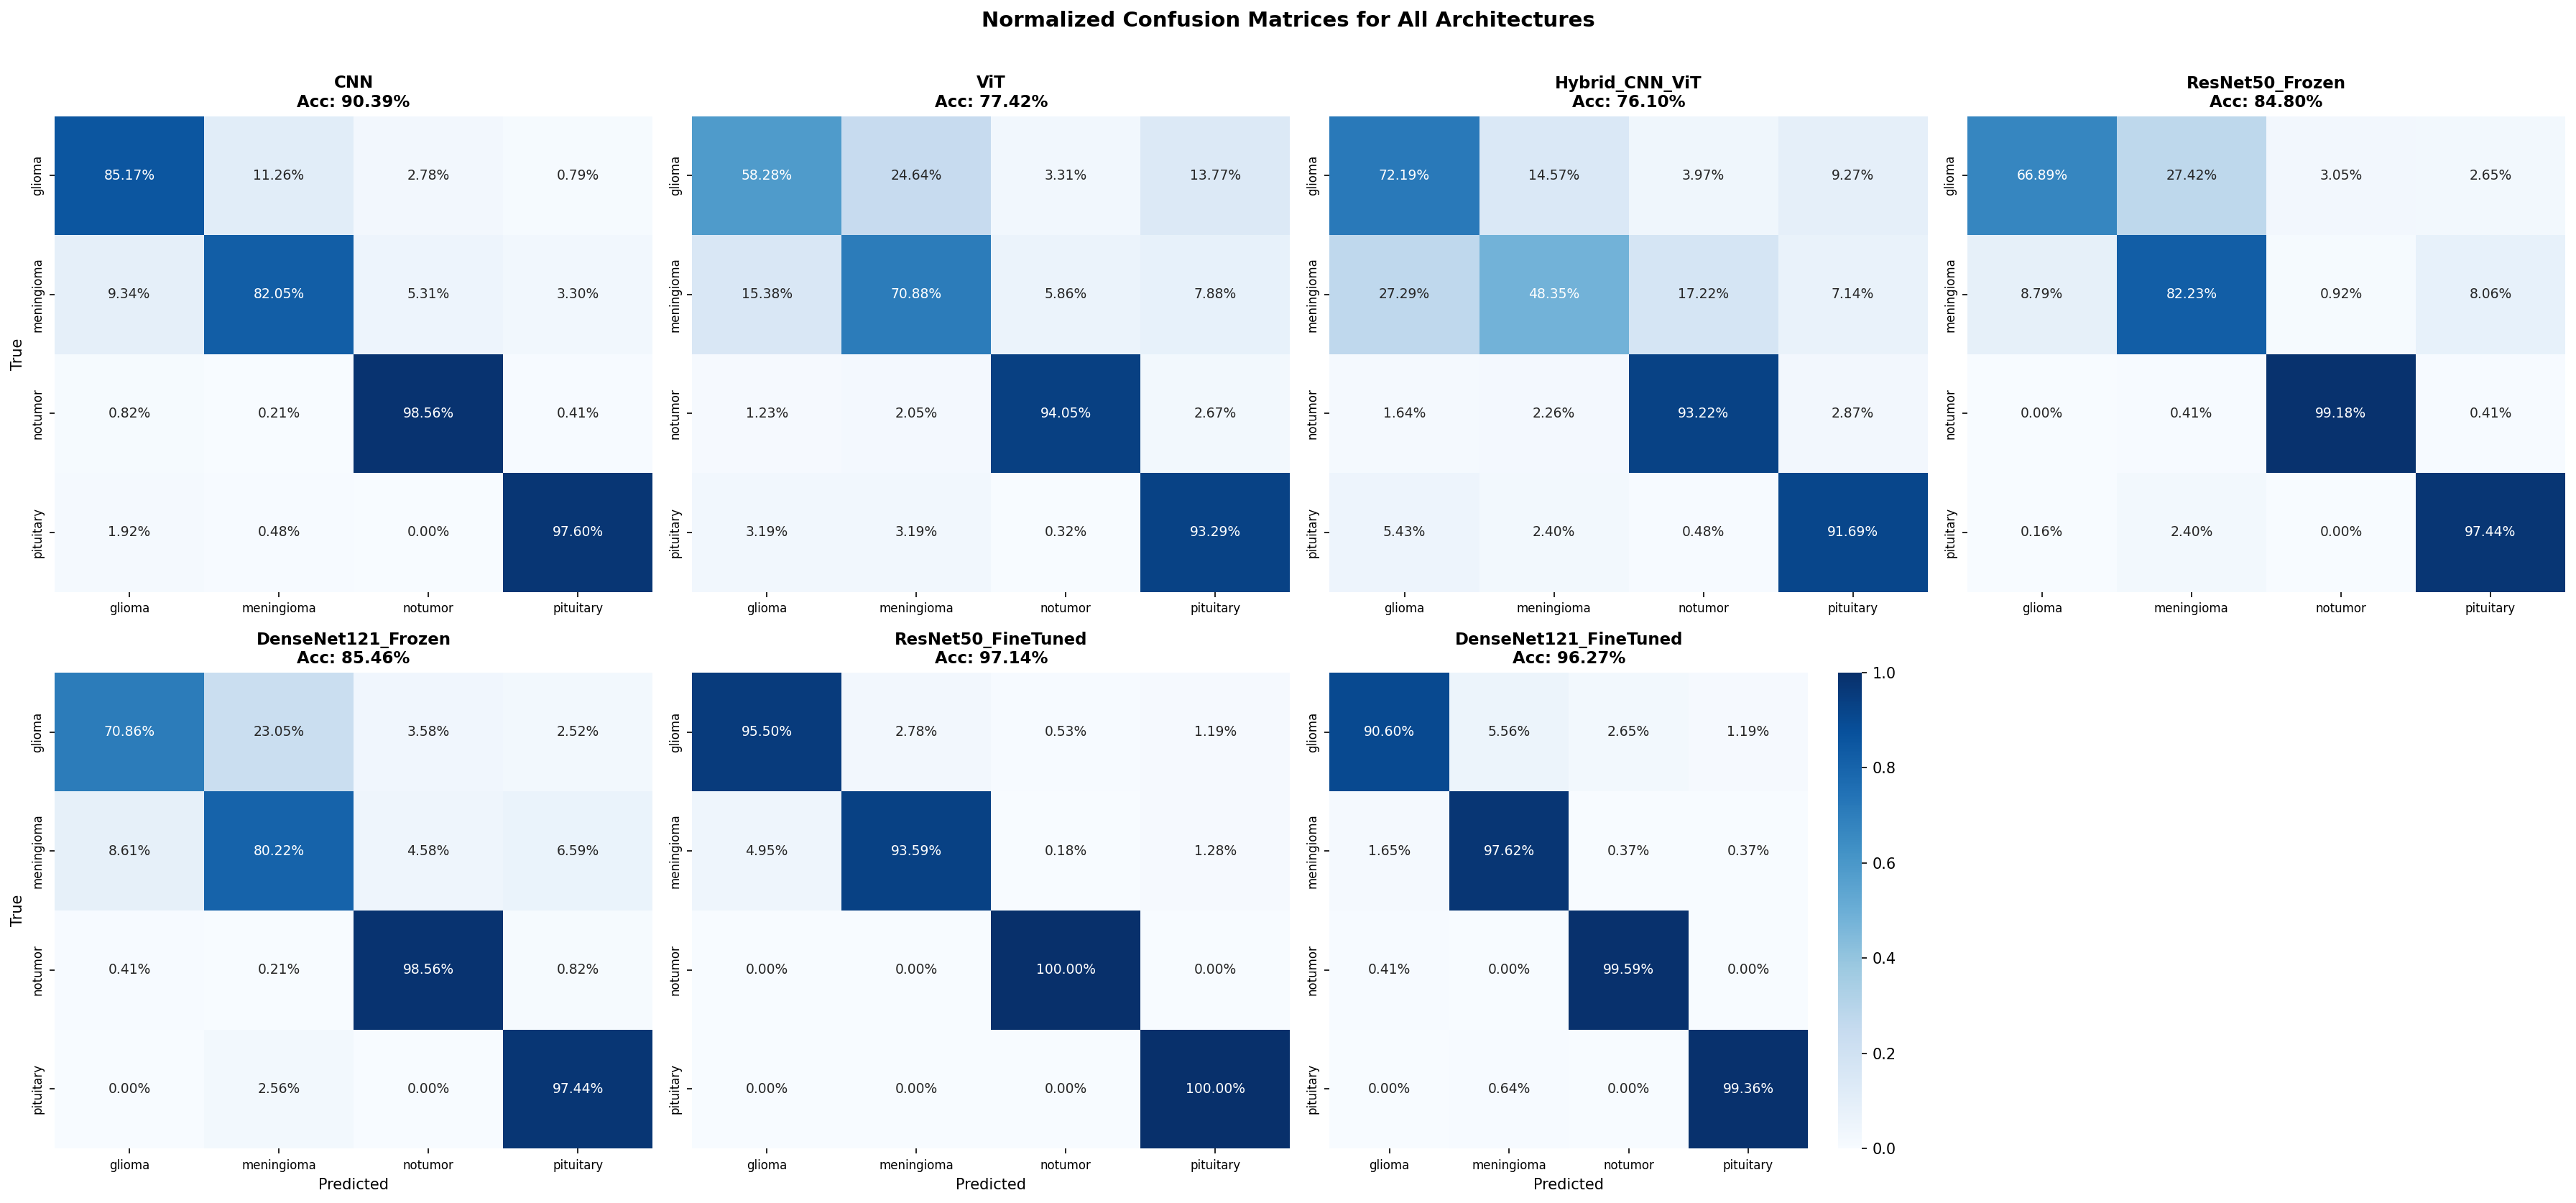

Figure 1 saved


In [ ]:
# =============================================================================
# CELL 7: Figure 1 — Normalized Confusion Matrices
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes_flat = axes.flatten()

for idx, (name, d) in enumerate(trained_models.items()):
    cm = confusion_matrix(d['y_true'], d['y_pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    ax = axes_flat[idx]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1, cbar=(idx == 6), annot_kws={'size': 9})
    ax.set_title(f'{name}\nAcc: {d["accuracy"]:.2%}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted' if idx >= 4 else '')
    ax.set_ylabel('True' if idx % 4 == 0 else '')
    ax.tick_params(labelsize=8)

axes_flat[7].axis('off')
plt.suptitle('Normalized Confusion Matrices for All Architectures',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
for path in [f'{FIG_DIR}/fig1_confusion_matrices.png', f'{SAVE_DIR}/fig1_confusion_matrices.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()
print("Figure 1 saved")

---
## CELL 8: Figure 2 — ROC Curves (All 7 Models)

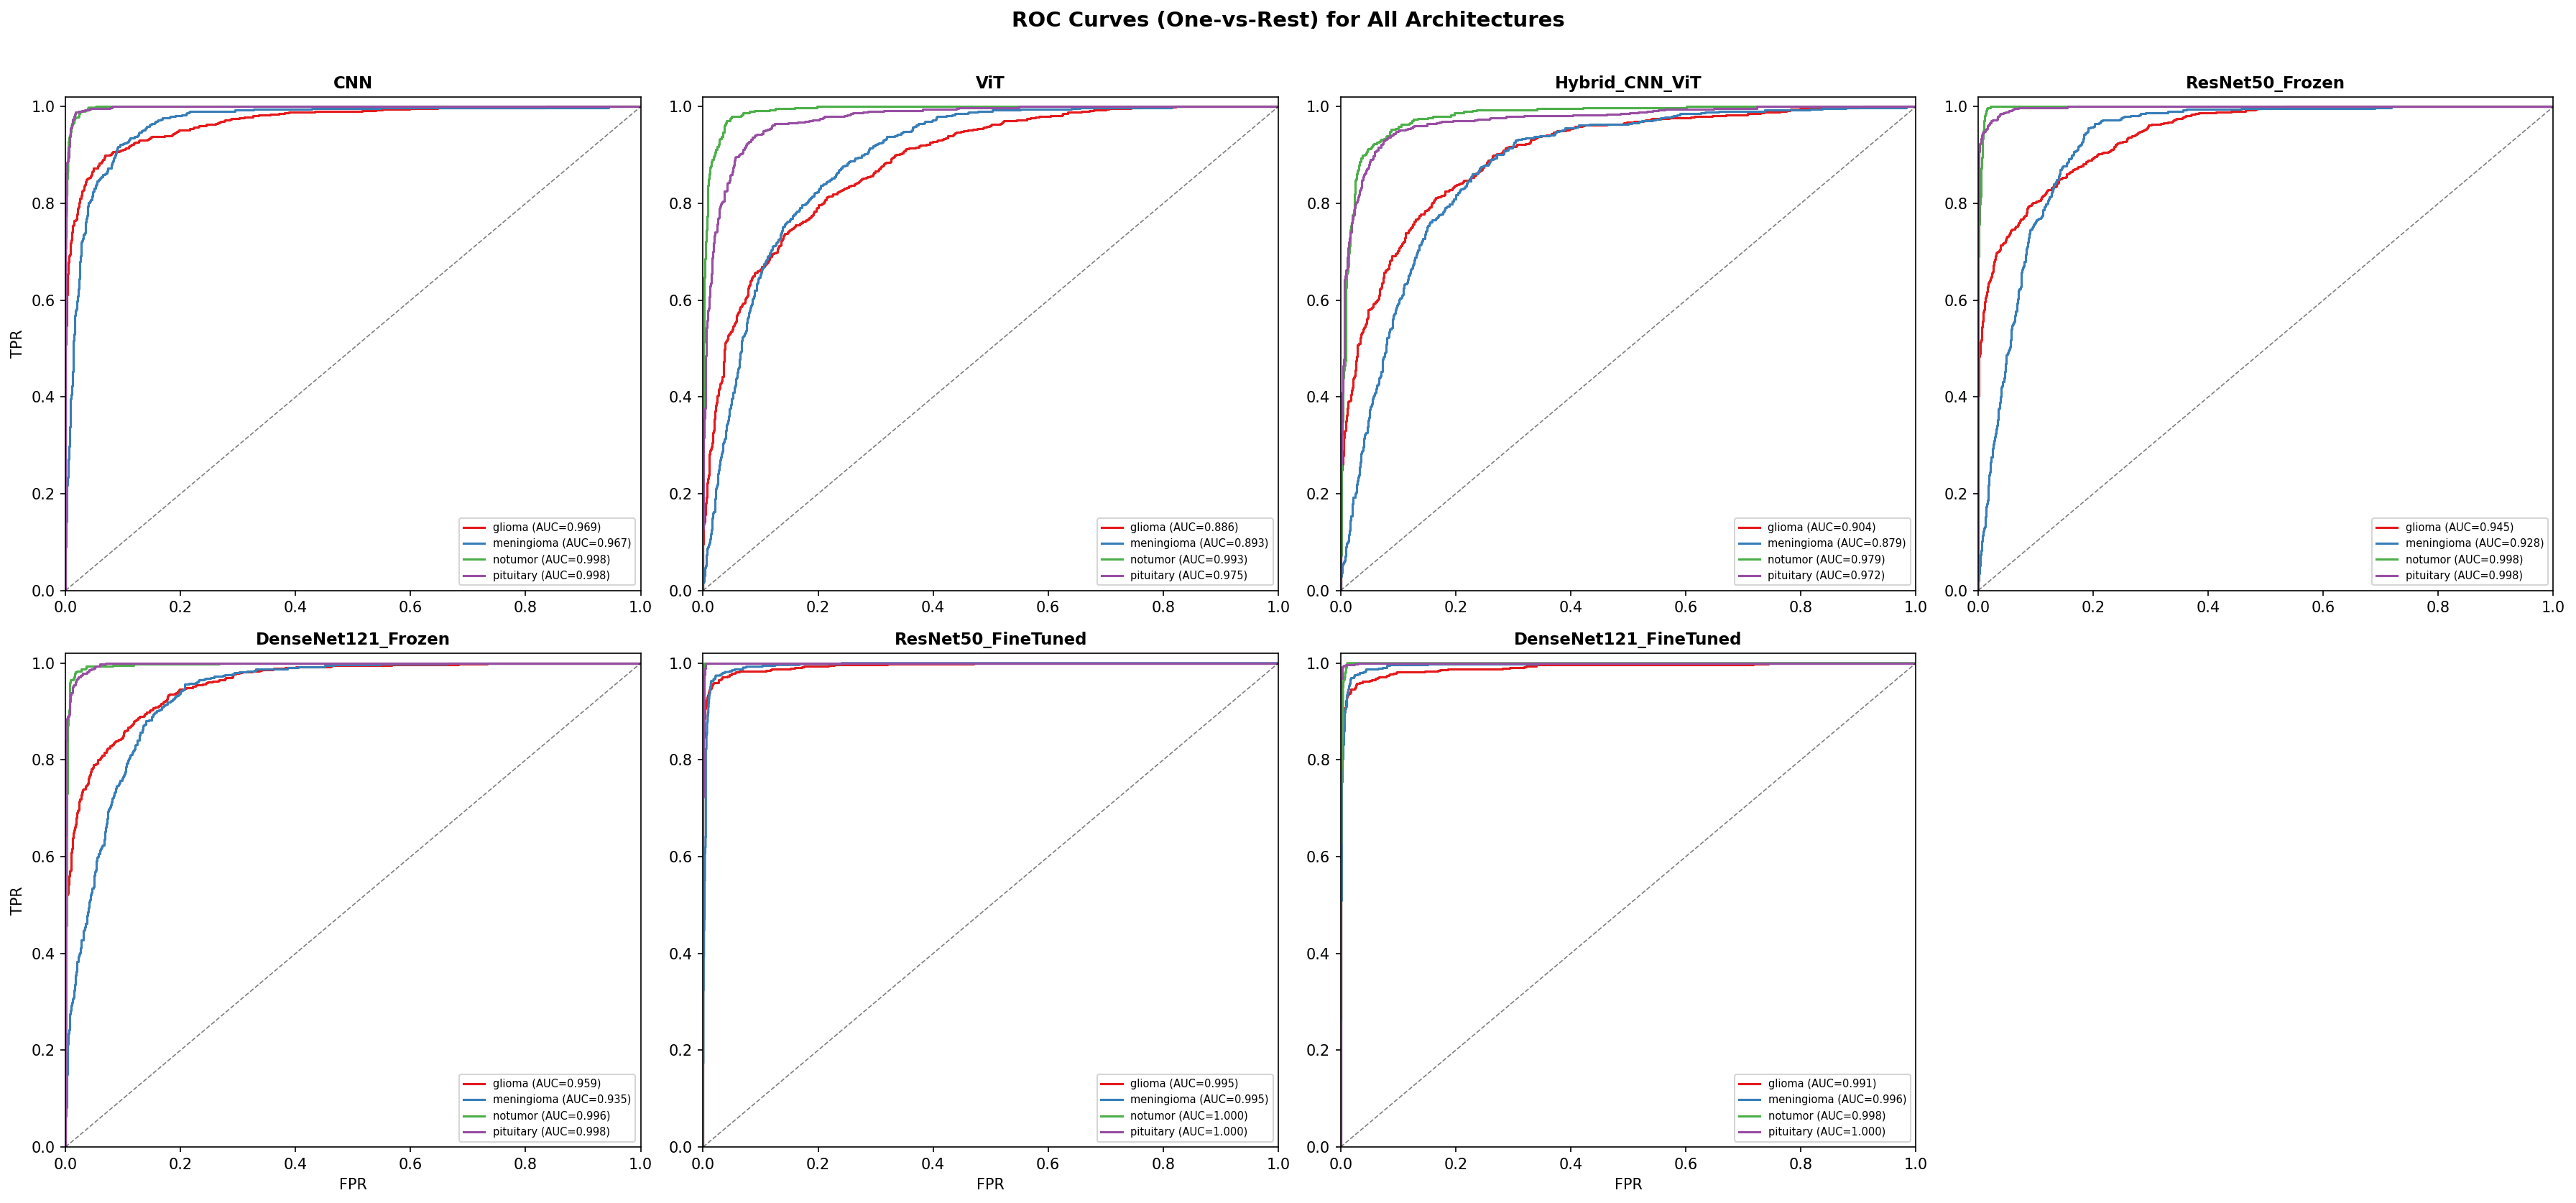


AUC-ROC Table (per model, per class):
Model                              glioma   meningioma      notumor    pituitary    Macro Avg
----------------------------------------------------------------------------------
  CNN                              0.9695       0.9668       0.9977       0.9984       0.9831
  ViT                              0.8861       0.8929       0.9929       0.9745       0.9366
  Hybrid_CNN_ViT                   0.9039       0.8788       0.9793       0.9717       0.9335
  ResNet50_Frozen                  0.9449       0.9277       0.9983       0.9977       0.9671
  DenseNet121_Frozen               0.9588       0.9349       0.9965       0.9976       0.9720
  ResNet50_FineTuned               0.9949       0.9947       1.0000       0.9996       0.9973
  DenseNet121_FineTuned            0.9912       0.9958       0.9984       0.9998       0.9963

Figure 2 saved


In [ ]:
# =============================================================================
# CELL 8: Figure 2 — ROC Curves (One-vs-Rest)
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes_flat = axes.flatten()
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Also collect AUC values for a summary table
auc_table = {}

for idx, (name, d) in enumerate(trained_models.items()):
    ax = axes_flat[idx]
    model_aucs = {}
    for c in range(NUM_CLASSES):
        y_bin = (d['y_true'] == c).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, d['y_prob'][:, c])
        roc_auc = auc(fpr, tpr)
        model_aucs[CLASS_NAMES[c]] = roc_auc
        ax.plot(fpr, tpr, color=colors[c], lw=1.5,
                label=f'{CLASS_NAMES[c]} (AUC={roc_auc:.3f})')
    ax.plot([0,1], [0,1], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel('FPR' if idx >= 4 else '')
    ax.set_ylabel('TPR' if idx % 4 == 0 else '')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    auc_table[name] = model_aucs

axes_flat[7].axis('off')
plt.suptitle('ROC Curves (One-vs-Rest) for All Architectures',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
for path in [f'{FIG_DIR}/fig2_roc_curves.png', f'{SAVE_DIR}/fig2_roc_curves.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()

# Print AUC table for the paper
print("\nAUC-ROC Table (per model, per class):")
print(f"{'Model':<28}", end='')
for cn in CLASS_NAMES:
    print(f" {cn:>12}", end='')
print(f" {'Macro Avg':>12}")
print('-' * 82)
for mn, aucs in auc_table.items():
    print(f"  {mn:<26}", end='')
    vals = list(aucs.values())
    for v in vals:
        print(f" {v:>12.4f}", end='')
    print(f" {np.mean(vals):>12.4f}")

print("\nFigure 2 saved")

---
## CELL 9: Figure 3 — Training Dynamics

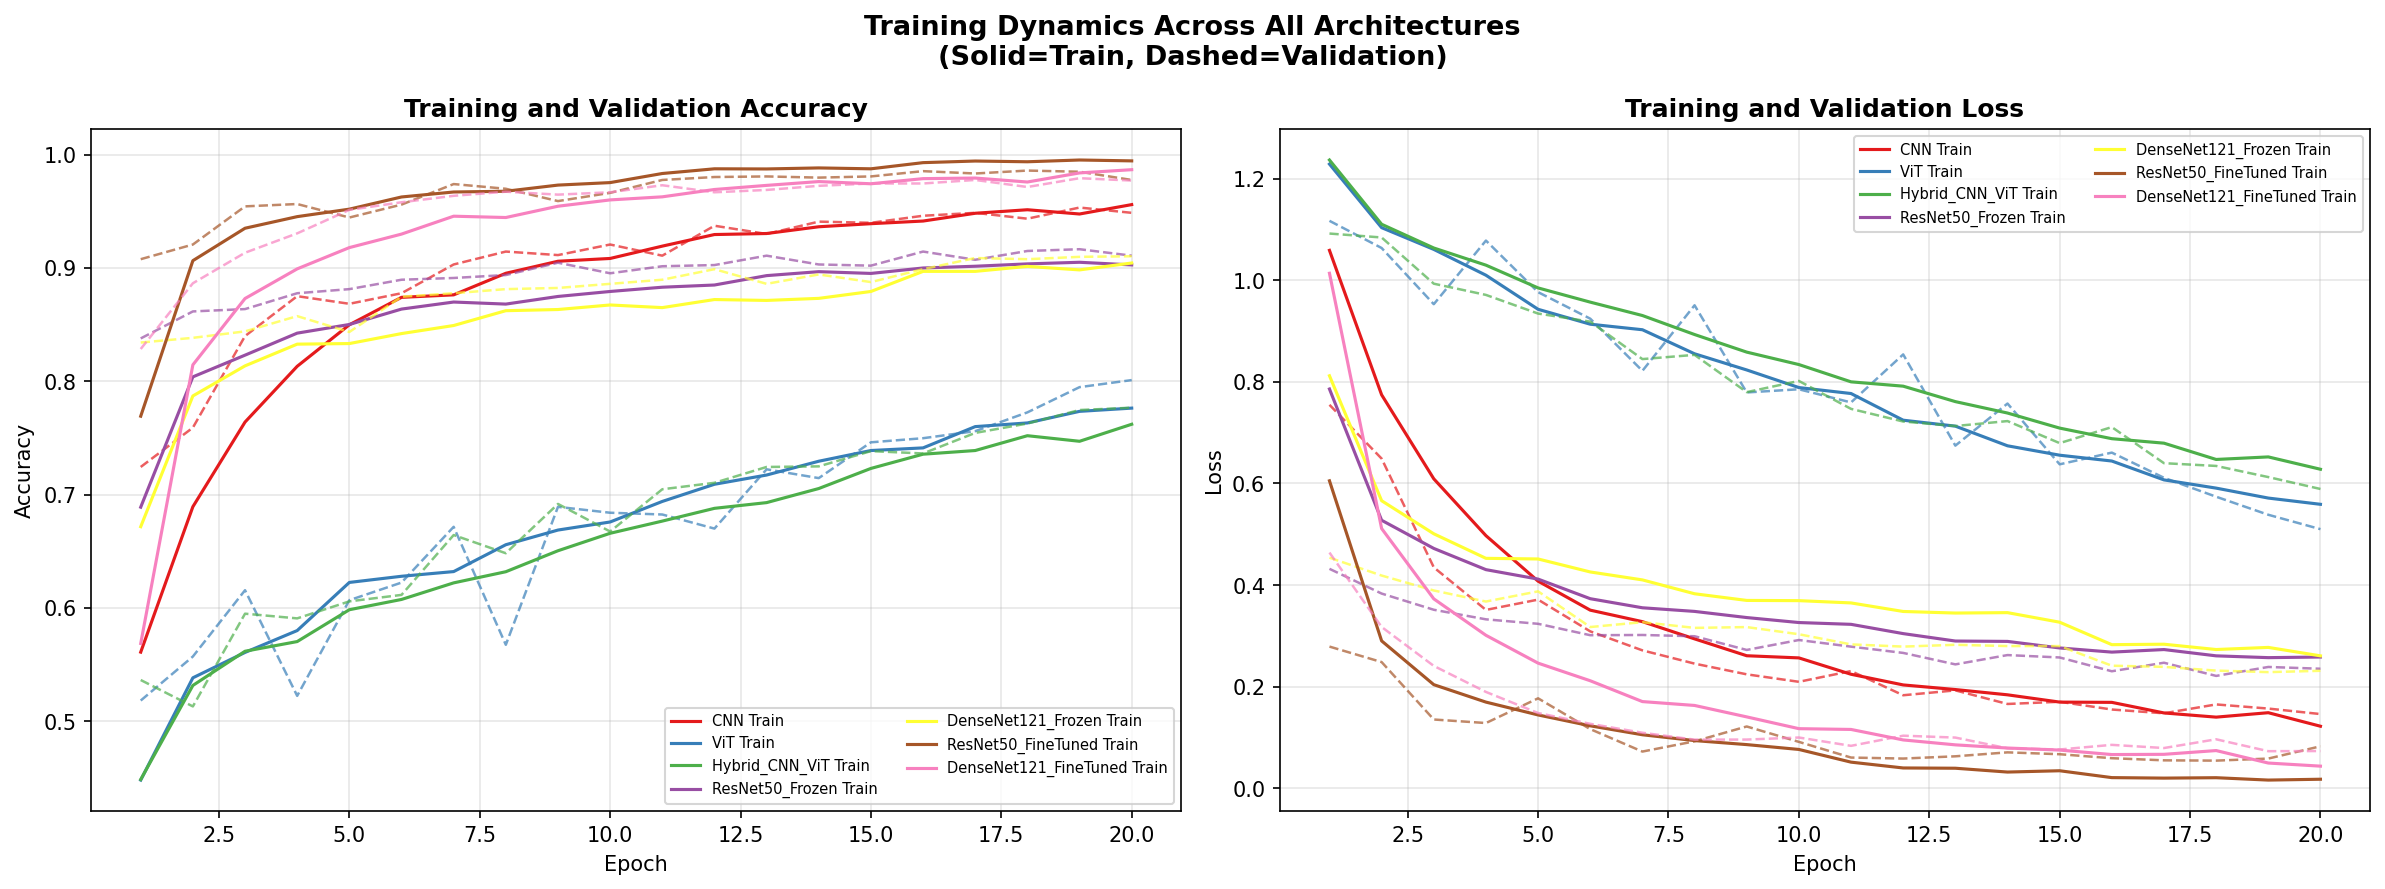

Figure 3 saved


In [ ]:
# =============================================================================
# CELL 9: Figure 3 — Training and Validation Accuracy/Loss Curves
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.cm.Set1
model_colors = {name: cmap(i / 7) for i, name in enumerate(trained_models)}

for name, d in trained_models.items():
    h = d['history']
    c = model_colors[name]
    epochs_range = range(1, len(h['accuracy']) + 1)
    ax1.plot(epochs_range, h['accuracy'], '-', color=c, lw=1.5, label=f'{name} Train')
    ax1.plot(epochs_range, h['val_accuracy'], '--', color=c, lw=1.2, alpha=0.7)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training and Validation Accuracy', fontweight='bold')
ax1.legend(fontsize=7, ncol=2, loc='lower right')
ax1.grid(True, alpha=0.3)

for name, d in trained_models.items():
    h = d['history']
    c = model_colors[name]
    epochs_range = range(1, len(h['loss']) + 1)
    ax2.plot(epochs_range, h['loss'], '-', color=c, lw=1.5, label=f'{name} Train')
    ax2.plot(epochs_range, h['val_loss'], '--', color=c, lw=1.2, alpha=0.7)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training and Validation Loss', fontweight='bold')
ax2.legend(fontsize=7, ncol=2, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Dynamics Across All Architectures\n(Solid=Train, Dashed=Validation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
for path in [f'{FIG_DIR}/fig3_training_curves.png', f'{SAVE_DIR}/fig3_training_curves.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()
print("Figure 3 saved")

---
## CELL 10: Figure 4 — Performance Comparison Bars

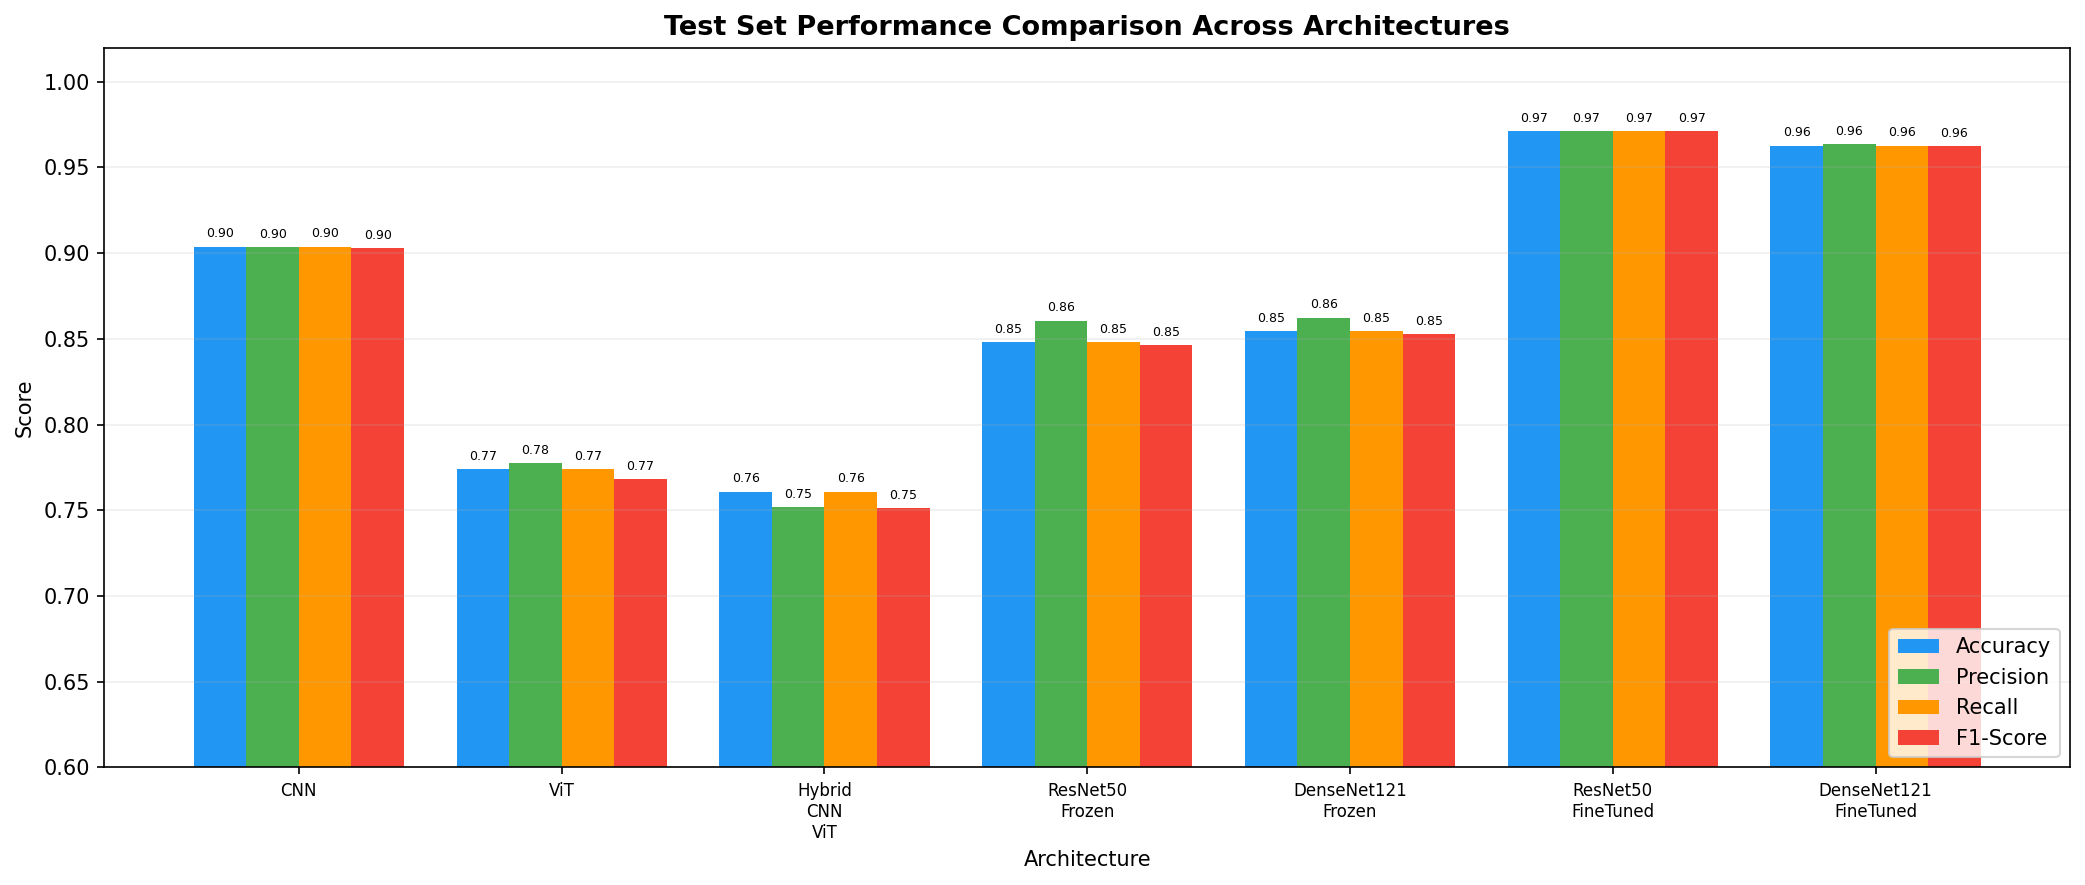

Figure 4 saved


In [ ]:
# =============================================================================
# CELL 10: Figure 4 — Bar Chart Comparison (Accuracy, Precision, Recall, F1)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

names_list = list(trained_models.keys())
x = np.arange(len(names_list))
width = 0.2

accs  = [trained_models[n]['accuracy'] for n in names_list]
f1s   = [trained_models[n]['f1'] for n in names_list]
precs = [precision_score(trained_models[n]['y_true'], trained_models[n]['y_pred'], average='weighted')
         for n in names_list]
recs  = [recall_score(trained_models[n]['y_true'], trained_models[n]['y_pred'], average='weighted')
         for n in names_list]

bars1 = ax.bar(x - 1.5*width, accs,  width, label='Accuracy',  color='#2196F3')
bars2 = ax.bar(x - 0.5*width, precs, width, label='Precision', color='#4CAF50')
bars3 = ax.bar(x + 0.5*width, recs,  width, label='Recall',    color='#FF9800')
bars4 = ax.bar(x + 1.5*width, f1s,   width, label='F1-Score',  color='#F44336')

ax.set_xlabel('Architecture')
ax.set_ylabel('Score')
ax.set_title('Test Set Performance Comparison Across Architectures', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([n.replace('_', '\n') for n in names_list], fontsize=8)
ax.legend(loc='lower right')
ax.set_ylim([0.6, 1.02])
ax.grid(True, alpha=0.2, axis='y')

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                   xytext=(0, 3), textcoords='offset points',
                   ha='center', va='bottom', fontsize=6)

plt.tight_layout()
for path in [f'{FIG_DIR}/fig4_comparison_bars.png', f'{SAVE_DIR}/fig4_comparison_bars.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()
print("Figure 4 saved")

---
## CELL 11: Figure 5 — t-SNE Feature Visualization

Computing t-SNE for CNN...


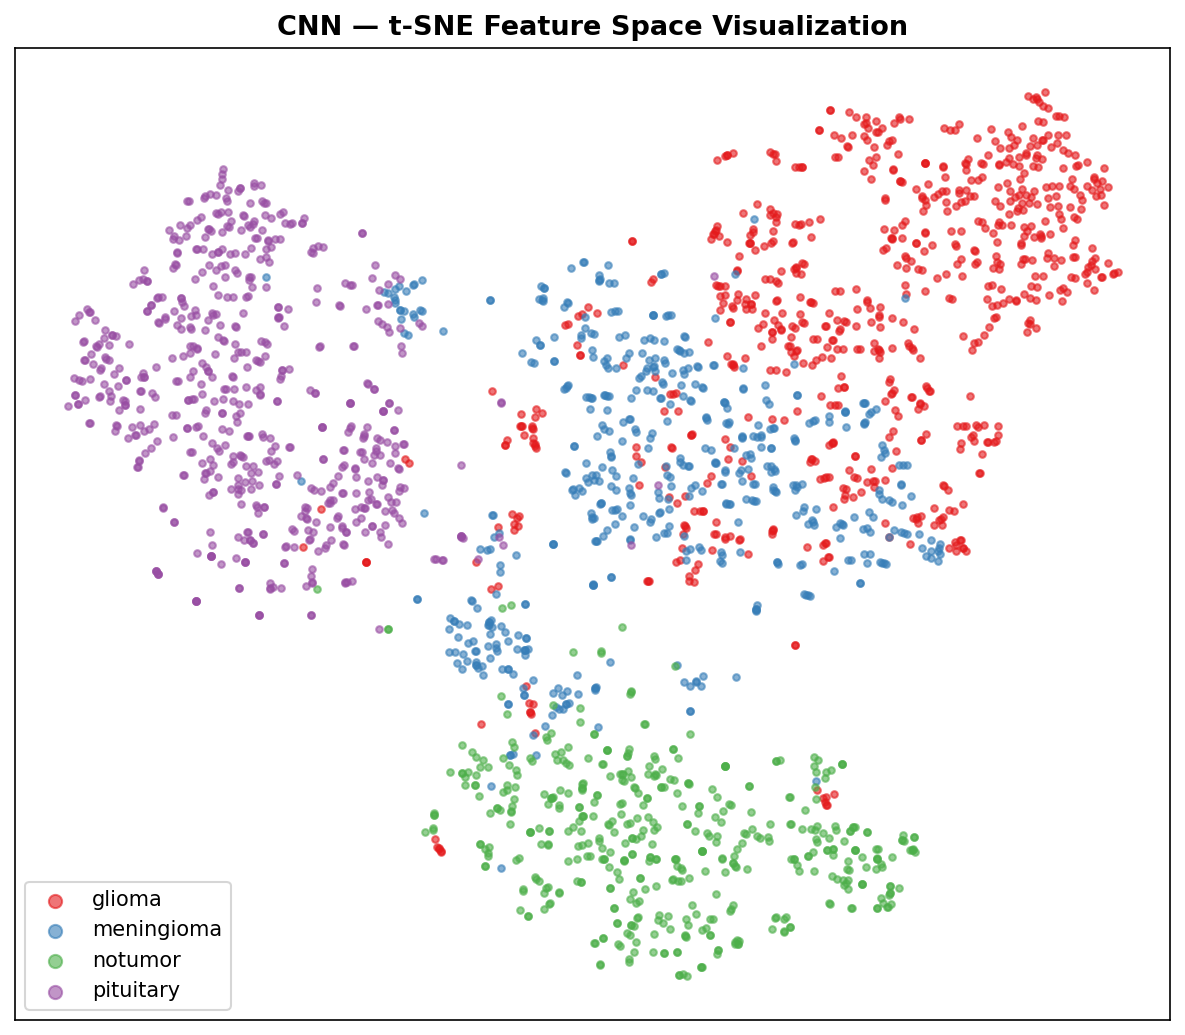

Figure 5 saved


In [ ]:
# =============================================================================
# CELL 11: Figure 5 — t-SNE Feature Space Visualization (CNN only for paper)
# =============================================================================

colors_tsne = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# CNN t-SNE (main figure for paper)
cnn_feats = trained_models['CNN']['features']
cnn_ytrue = trained_models['CNN']['y_true']

if cnn_feats is not None and len(cnn_feats.shape) == 2:
    print("Computing t-SNE for CNN...")
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    embedded = tsne.fit_transform(cnn_feats)

    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(NUM_CLASSES):
        mask = cnn_ytrue == c
        ax.scatter(embedded[mask, 0], embedded[mask, 1],
                  c=colors_tsne[c], label=CLASS_NAMES[c], s=10, alpha=0.6)
    ax.set_title('CNN — t-SNE Feature Space Visualization', fontweight='bold', fontsize=13)
    ax.legend(fontsize=10, markerscale=2)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    for path in [f'{FIG_DIR}/fig5_tsne.png', f'{SAVE_DIR}/fig5_tsne.png']:
        plt.savefig(path, bbox_inches='tight', dpi=300)
    plt.show()
    print("Figure 5 saved")
else:
    print("CNN features not available for t-SNE")

---
## CELL 12: Figure 6 — Grad-CAM Visualization (CNN)

Retraining CNN for Grad-CAM...
Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.5648 - loss: 1.0333 - val_accuracy: 0.7083 - val_loss: 0.7840
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.6911 - loss: 0.7650 - val_accuracy: 0.7984 - val_loss: 0.5947
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.7803 - loss: 0.5716 - val_accuracy: 0.8415 - val_loss: 0.4220
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.8304 - loss: 0.4485 - val_accuracy: 0.8725 - val_loss: 0.3566
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.8563 - loss: 0.3860 - val_accuracy: 0.8813 - val_loss: 0.3265
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.8731 - loss: 0.3482 - val_accuracy: 0.8839 - val_loss: 0.3038
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.8913 - loss: 0.3113 - val_accuracy: 0.9036 - val_loss: 0.2590
Epoch 8/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - ac

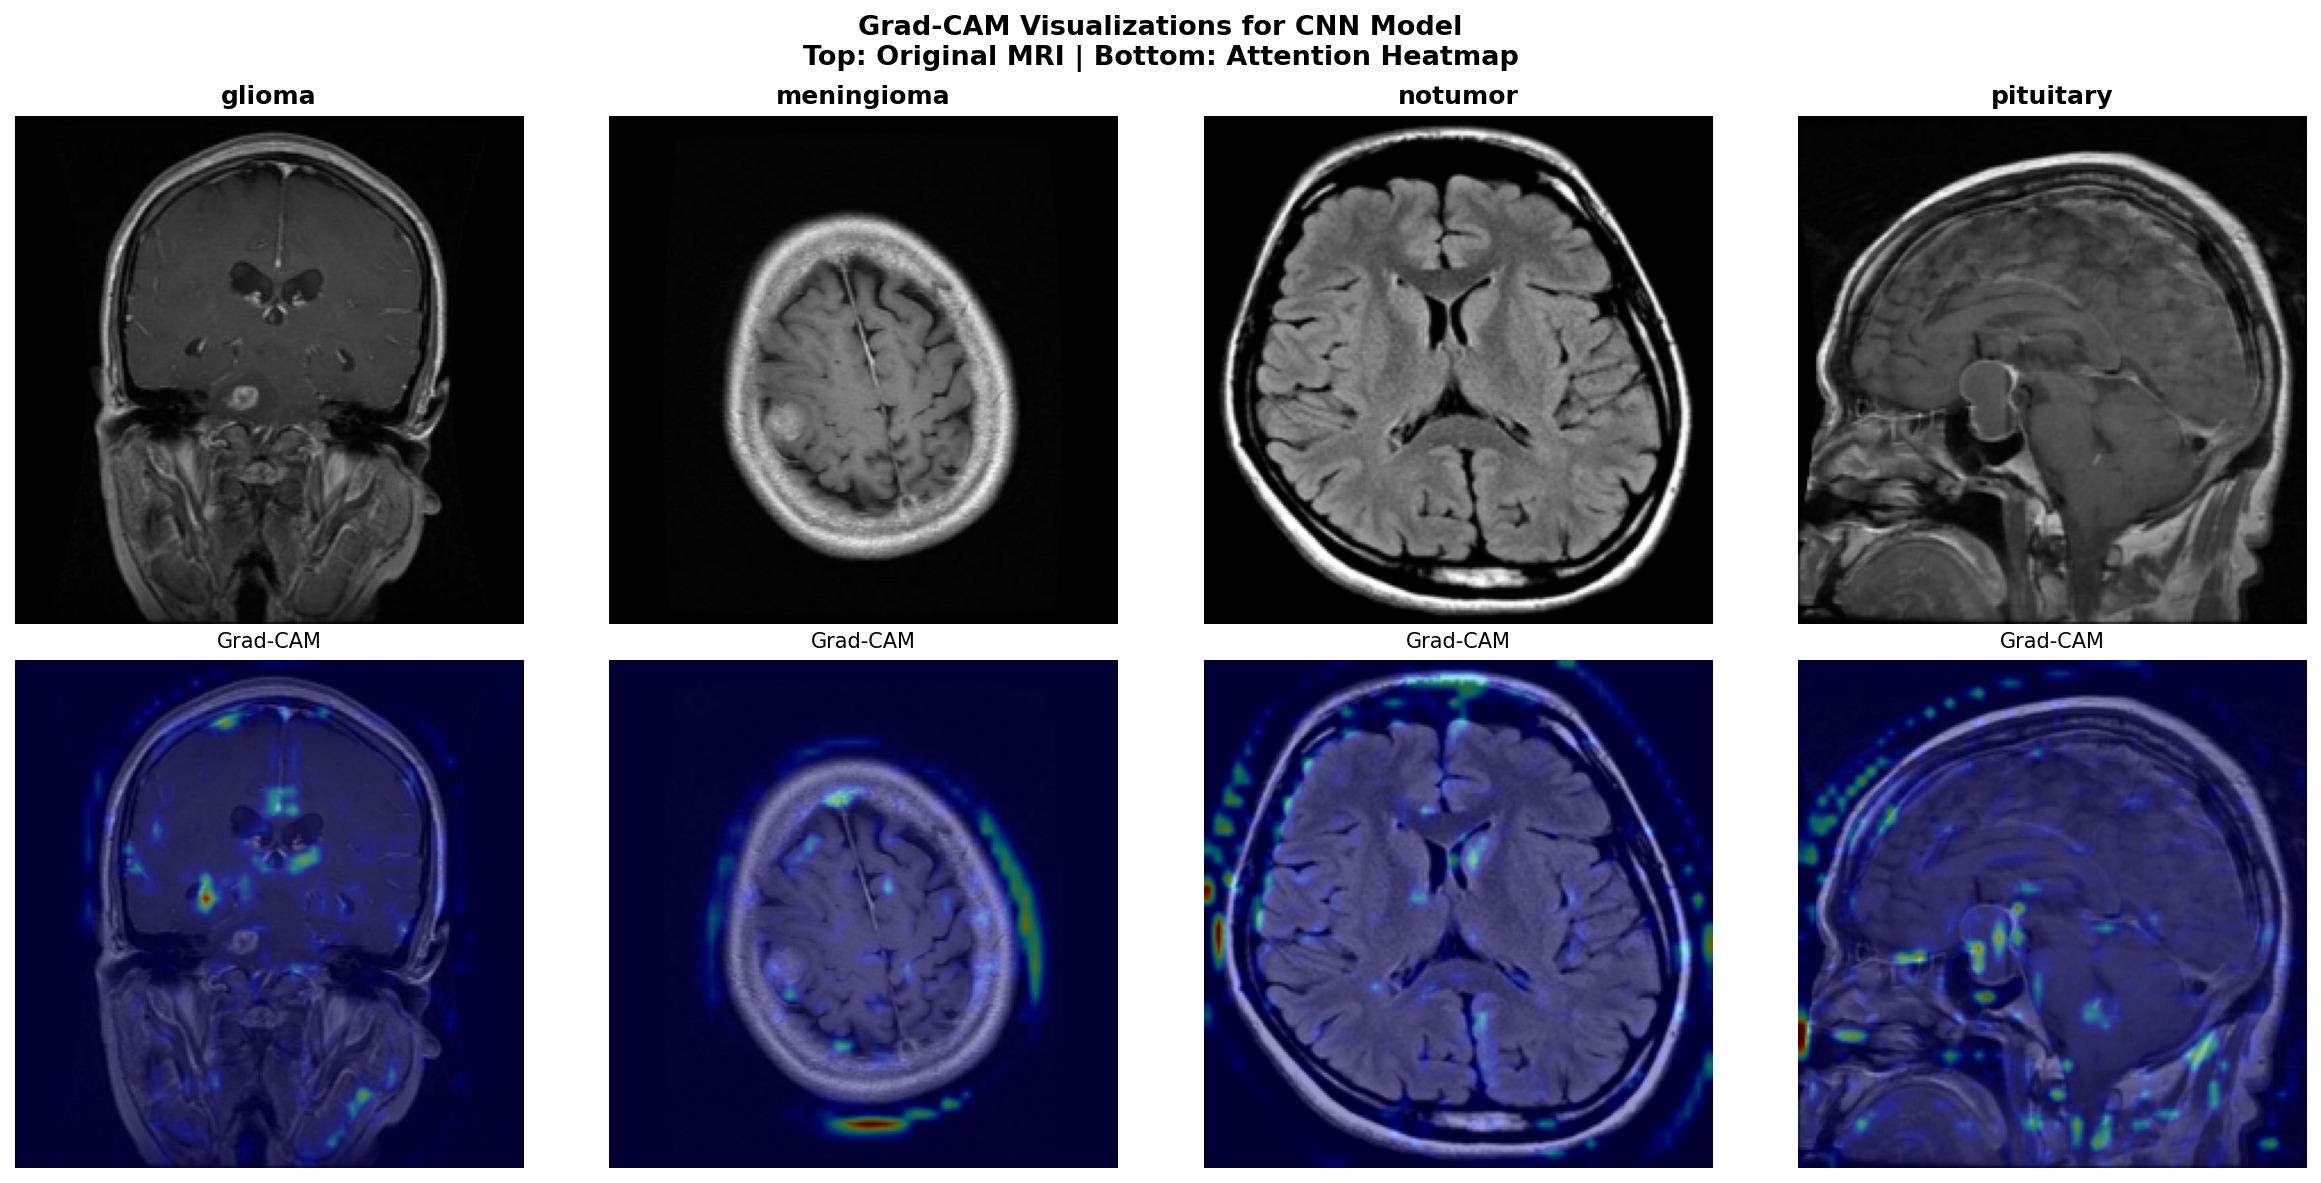

Figure 6 saved


In [ ]:
# =============================================================================
# CELL 12: Figure 6 — Grad-CAM Visualization for CNN (retrains CNN)
# =============================================================================
import gc

def make_gradcam_heatmap(img_array, model, last_conv_name):
    """Generate Grad-CAM heatmap for the predicted class."""
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_channel = preds[:, tf.argmax(preds[0])]
    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Retrain CNN quickly for Grad-CAM (model was freed in Cell 6B)
print("Retraining CNN for Grad-CAM...")
tf.keras.backend.clear_session()
gc.collect()

cnn_model = build_cnn()
tr_ds = create_dataset(tr_paths, tr_labels, batch_size=32, augment=True)
va_ds = create_dataset(val_paths, val_labels, batch_size=32, augment=False, shuffle=False)
cnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(tr_ds, validation_data=va_ds, epochs=20,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                        restore_best_weights=True, verbose=0)], verbose=1)
del tr_ds, va_ds
gc.collect()

# Get predictions for this model
cnn_ypred = np.argmax(np.concatenate([cnn_model.predict(bi, verbose=0) for bi, _ in test_dataset]), axis=1)
cnn_ytrue = trained_models['CNN']['y_true']

# Load test images
print("\nLoading test images for Grad-CAM...")
test_ds_single = create_dataset(test_paths, test_labels, batch_size=1, augment=False, shuffle=False)
all_test_images = np.concatenate([bi.numpy() for bi, _ in test_ds_single])
print(f"Loaded {len(all_test_images)} images")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for c in range(NUM_CLASSES):
    idxs = np.where((cnn_ytrue == c) & (cnn_ypred == c))[0]
    if len(idxs) == 0:
        idxs = np.where(cnn_ytrue == c)[0]
    si = idxs[0]
    img = all_test_images[si]

    axes[0, c].imshow(img)
    axes[0, c].set_title(CLASS_NAMES[c], fontweight='bold', fontsize=12)
    axes[0, c].axis('off')

    heatmap = make_gradcam_heatmap(np.expand_dims(img, 0), cnn_model, 'conv3')
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.6 * img + 0.4 * heatmap_color, 0, 1)
    axes[1, c].imshow(overlay)
    axes[1, c].set_title('Grad-CAM', fontsize=10)
    axes[1, c].axis('off')

plt.suptitle('Grad-CAM Visualizations for CNN Model\nTop: Original MRI | Bottom: Attention Heatmap',
             fontsize=13, fontweight='bold')
plt.tight_layout()
for path in [f'{FIG_DIR}/fig6_gradcam_cnn.png', f'{SAVE_DIR}/fig6_gradcam_cnn.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()

# Cleanup
del all_test_images, cnn_model
tf.keras.backend.clear_session()
gc.collect()
print("Figure 6 saved")

---
## CELL 13: Figure 7 — Computational Efficiency

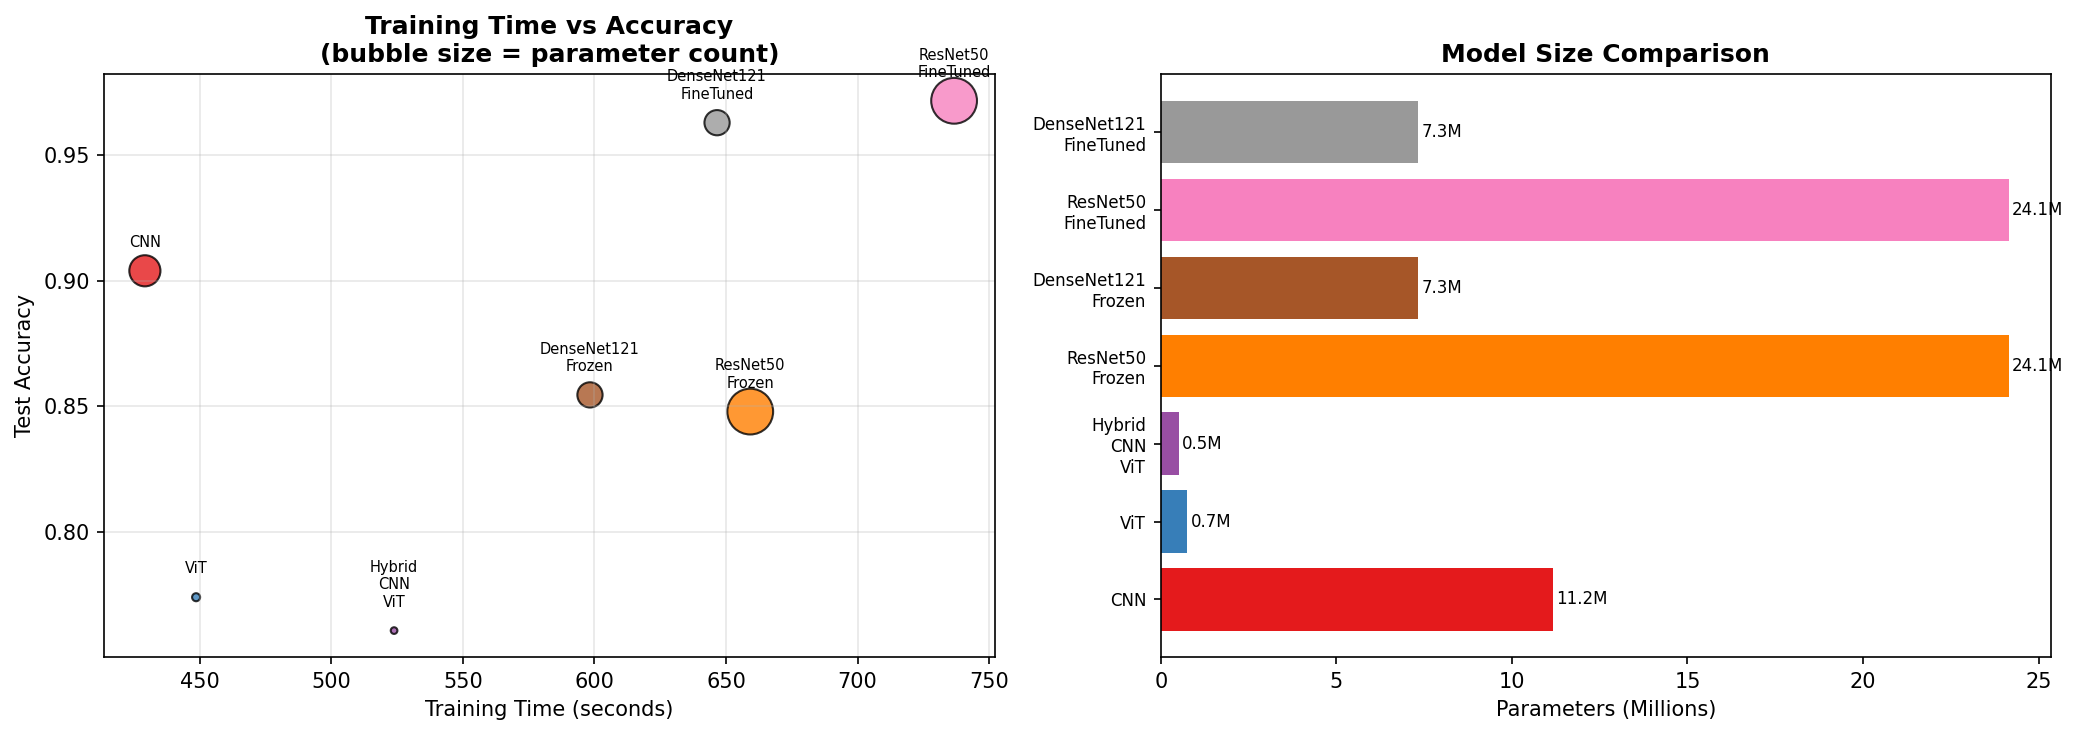

Figure 7 saved


In [ ]:
# =============================================================================
# CELL 13: Figure 7 — Training Time vs Accuracy + Model Size
# =============================================================================

# Get parameter counts
param_counts = {}
for name, cfg in MODEL_CONFIGS.items():
    m = cfg['build_fn']()
    param_counts[name] = {
        'total': int(np.sum([np.prod(v.shape) for v in m.weights])),
        'trainable': int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))
    }
    del m
    tf.keras.backend.clear_session()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = list(trained_models.keys())
times = [trained_models[n]['time'] for n in names]
params = [param_counts[n]['total'] for n in names]
accs_plot = [trained_models[n]['accuracy'] for n in names]

# Left: Training time vs Accuracy (bubble = params)
scatter = ax1.scatter(times, accs_plot, s=[p/50000 for p in params],
                     c=range(len(names)), cmap='Set1', alpha=0.8, edgecolors='black')
for i, n in enumerate(names):
    ax1.annotate(n.replace('_', '\n'), (times[i], accs_plot[i]),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points')
ax1.set_xlabel('Training Time (seconds)')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Training Time vs Accuracy\n(bubble size = parameter count)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Right: Parameter count bars
colors_bar = plt.cm.Set1(np.linspace(0, 1, len(names)))
bars = ax2.barh(range(len(names)), [p/1e6 for p in params], color=colors_bar)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels([n.replace('_', '\n') for n in names], fontsize=8)
ax2.set_xlabel('Parameters (Millions)')
ax2.set_title('Model Size Comparison', fontweight='bold')
for i, bar in enumerate(bars):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{params[i]/1e6:.1f}M', va='center', fontsize=8)

plt.tight_layout()
for path in [f'{FIG_DIR}/fig7_efficiency.png', f'{SAVE_DIR}/fig7_efficiency.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()
print("Figure 7 saved")

In [ ]:
# =============================================================================
# CELL 13 FIX: Figure 7 — Improved Efficiency Plot
# =============================================================================

# Get parameter counts
param_counts = {}
for name, cfg in MODEL_CONFIGS.items():
    m = cfg['build_fn']()
    param_counts[name] = {
        'total': int(np.sum([np.prod(v.shape) for v in m.weights])),
        'trainable': int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))
    }
    del m
    tf.keras.backend.clear_session()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

names = list(trained_models.keys())
times = [trained_models[n]['time'] for n in names]
params = [param_counts[n]['total'] for n in names]
accs_plot = [trained_models[n]['accuracy'] for n in names]

# Left: Training time vs Accuracy (bubble = params)
scatter = ax1.scatter(times, accs_plot, s=[p/30000 for p in params],
                     c=range(len(names)), cmap='Set1', alpha=0.8, edgecolors='black', linewidths=1)

# Smart label placement with offsets to avoid overlap
offsets = {
    'CNN':                   (-40, -20),
    'ViT':                   (10, -15),
    'Hybrid_CNN_ViT':        (10, -15),
    'ResNet50_Frozen':       (10, -18),
    'DenseNet121_Frozen':    (-60, -18),
    'ResNet50_FineTuned':    (-50, 12),
    'DenseNet121_FineTuned': (-70, 12),
}
for i, n in enumerate(names):
    ox, oy = offsets.get(n, (0, 10))
    ax1.annotate(n.replace('_', '\n'), (times[i], accs_plot[i]),
                fontsize=7, ha='center', va='center',
                xytext=(ox, oy), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5) if abs(ox) > 15 else None)

ax1.set_xlabel('Training Time (seconds)')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Training Time vs Accuracy\n(bubble size = parameter count)', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([min(times)-50, max(times)+80])
ax1.set_ylim([min(accs_plot)-0.03, max(accs_plot)+0.03])

# Right: Parameter count bars
colors_bar = plt.cm.Set1(np.linspace(0, 1, len(names)))
bars = ax2.barh(range(len(names)), [p/1e6 for p in params], color=colors_bar)
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels([n.replace('_', '\n') for n in names], fontsize=8)
ax2.set_xlabel('Parameters (Millions)')
ax2.set_title('Model Size Comparison', fontweight='bold')
ax2.set_xlim([0, max(params)/1e6 * 1.2])
for i, bar in enumerate(bars):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{params[i]/1e6:.1f}M', va='center', fontsize=8)

plt.tight_layout()
for path in [f'{FIG_DIR}/fig7_efficiency.png', f'{SAVE_DIR}/fig7_efficiency.png']:
    plt.savefig(path, bbox_inches='tight', dpi=300)
plt.show()
print("Figure 7 (fixed) saved")

NameError: name 'MODEL_CONFIGS' is not defined

---
## CELL 14: Paper-Ready Summary Table + Save Everything

In [ ]:
# =============================================================================
# CELL 14: Paper-Ready Summary + CSV Export
# =============================================================================

# Rebuild param counts
param_counts = {}
for name, cfg in MODEL_CONFIGS.items():
    m = cfg['build_fn']()
    param_counts[name] = {
        'total': int(np.sum([np.prod(v.shape) for v in m.weights])),
        'trainable': int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))
    }
    del m
    tf.keras.backend.clear_session()

print("="*90)
print("PAPER-READY RESULTS TABLE")
print("="*90)

rows = []
for mn, r in all_results.items():
    yt = np.array(r['test_true'])
    yp = np.array(r['test_predictions'][r['best_fold']])
    rows.append({
        'Architecture': mn,
        'Total_Params': f"{param_counts[mn]['total']:,}",
        'Trainable_Params': f"{param_counts[mn]['trainable']:,}",
        'CV_Accuracy': f"{r['cv_accuracy_mean']:.4f}+/-{r['cv_accuracy_std']:.4f}",
        'CV_F1': f"{r['cv_f1_mean']:.4f}+/-{r['cv_f1_std']:.4f}",
        'Folds': r['n_folds'],
        'Test_Accuracy': f"{accuracy_score(yt, yp):.4f}",
        'Test_Precision': f"{precision_score(yt, yp, average='weighted'):.4f}",
        'Test_Recall': f"{recall_score(yt, yp, average='weighted'):.4f}",
        'Test_F1': f"{f1_score(yt, yp, average='weighted'):.4f}",
        'Avg_Time_s': f"{r['mean_time']:.0f}",
    })

paper_df = pd.DataFrame(rows)
print(paper_df.to_string(index=False))

# Save CSV
csv_path = os.path.join(SAVE_DIR, 'results_table.csv')
paper_df.to_csv(csv_path, index=False)
print(f"\nCSV saved to: {csv_path}")

# Final figure list
print("\n" + "="*70)
print("ALL OUTPUTS")
print("="*70)
for f in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {f} ({size_kb:.0f} KB)")

print("\n" + "="*70)
print("ALL COMPLETE!")
print("="*70)
print(f"\nAll results saved to Google Drive at: {SAVE_DIR}")
print("\nFiles:")
print("  cv_checkpoint.json        — Raw CV results (all folds)")
print("  full_results.json         — CV + McNemar + Wilcoxon")
print("  results_table.csv         — Paper-ready table")
print("  fig1_confusion_matrices.png")
print("  fig2_roc_curves.png")
print("  fig3_training_curves.png")
print("  fig4_comparison_bars.png")
print("  fig5_tsne.png")
print("  fig6_gradcam_cnn.png")
print("  fig7_efficiency.png")

PAPER-READY RESULTS TABLE
         Architecture Total_Params Trainable_Params     CV_Accuracy           CV_F1  Folds Test_Accuracy Test_Precision Test_Recall Test_F1 Avg_Time_s
                  CNN   11,169,476       11,169,476 0.9576+/-0.0048 0.9577+/-0.0047      5        0.9209         0.9211      0.9209  0.9201        373
                  ViT      744,452          744,452 0.8084+/-0.0130 0.8062+/-0.0143      5        0.7958         0.8100      0.7958  0.7928        433
       Hybrid_CNN_ViT      513,156          513,156 0.7753+/-0.0210 0.7729+/-0.0216      5        0.7647         0.7688      0.7647  0.7616        537
      ResNet50_Frozen   24,145,668          557,956 0.9337+/-0.0062 0.9337+/-0.0064      5        0.8679         0.8765      0.8679  0.8677        686
   DenseNet121_Frozen    7,333,316          295,812 0.9181+/-0.0104 0.9185+/-0.0102      5        0.8608         0.8667      0.8608  0.8608        619
   ResNet50_FineTuned   24,145,668        9,489,284 0.9830+/-0.0031 